## Imports

In [ ]:
from google.colab import drive
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/final_FYP_results/test_preprocess'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [ ]:
# !pip install keras-tcn
!pip install keras-tcn --no-dependencies  # without the dependencies if you already have TF/Numpy.

In [ ]:
import random
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
# from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.corpus import stopwords

# import gensim
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings(action = 'ignore')

import shutil

import tensorflow_hub as hub
import tensorflow_text as text
# from official.nlp import optimization  # to create AdamW optimizer

tf.get_logger().setLevel('ERROR')

import kagglehub

import ast

import sklearn
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
import time

from tabulate import tabulate

import gc

def set_all_seeds(seed):
  """Sets the seed for all relevant random number generators."""
  os.environ['PYTHONHASHSEED'] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)
  # tf.config.experimental.enable_op_determinism()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
FOLDS=5
seed_value = 42
set_all_seeds(seed_value)

In [ ]:
#Preprocessing function
def preprocessing_old(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # # Removing stopwords
    stop = stopwords.words('english')
    data_frame['Text'].apply(lambda x: [item for item in str(x) if item not in stop])

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    # Tokenizing Posts and counting the length of each post
    data_frame['Tokens'] = data_frame.apply(lambda row: word_tokenize(str(row['Text'])), axis=1)
    data_frame['Length'] = data_frame.apply(lambda row: len(row['Tokens']), axis=1)

    return data_frame

In [ ]:
def preprocessing_new_rm_dupNaN(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    # Drop NaN
    data_frame = data_frame.dropna(subset=['Text'])

    # Just show duplicate
    duplicates = data_frame[data_frame.duplicated(subset=['Text', 'Label'], keep=False)]
    duplicates = duplicates.sort_values(by=['Text', 'Label'])
    # Display result
    print("Duplicates:")
    print(duplicates)

    # Drop Dup
    data_frame = data_frame.drop_duplicates(subset=['Text','Label'])

    # Tokenizing Posts and counting the length of each post
    data_frame['Tokens'] = data_frame.apply(lambda row: word_tokenize(str(row['Text'])), axis=1)
    data_frame['Length'] = data_frame.apply(lambda row: len(row['Tokens']), axis=1)

    return data_frame

In [ ]:
def preprocessing_new(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    data_frame = data_frame.dropna(subset=['Text'])

    # Tokenize
    data_frame['Tokens'] = data_frame['Text'].apply(word_tokenize)

    # # Removing stopwords
    stop =  set(stopwords.words('english'))
    data_frame['Tokens'] = data_frame['Tokens'].apply(lambda tokens: [word for word in tokens if word not in stop])
    data_frame['Text'] = data_frame['Tokens'].apply(lambda tokens: ' '.join(tokens))

    # 10. Length of each token list
    data_frame['Length'] = data_frame['Tokens'].apply(len)

    data_frame = data_frame.dropna(subset=['Text'])

    # Just show duplicate
    duplicates = data_frame[data_frame.duplicated(subset=['Text', 'Label'], keep=False)]
    duplicates = duplicates.sort_values(by=['Text', 'Label'])
    # Display result
    print("Duplicates:")
    print(duplicates)

    data_frame = data_frame.drop_duplicates(subset=['Text','Label'])

    return data_frame

In [ ]:
def preprocessing_new_rm_stop_NaN(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    data_frame = data_frame.dropna(subset=['Text'])

    # Tokenize
    data_frame['Tokens'] = data_frame['Text'].apply(word_tokenize)

    # # Removing stopwords
    stop =  set(stopwords.words('english'))
    data_frame['Tokens'] = data_frame['Tokens'].apply(lambda tokens: [word for word in tokens if word not in stop])
    data_frame['Text'] = data_frame['Tokens'].apply(lambda tokens: ' '.join(tokens))

    # 10. Length of each token list
    data_frame['Length'] = data_frame['Tokens'].apply(len)

    data_frame = data_frame.dropna(subset=['Text'])

    return data_frame

In [ ]:
def extract_feature_bert(preprocessor, encoder, texts, seq_len=128, embedding_dim=512, batch_size=64):
    # Set layers to non-trainable for feature extraction
    encoder.trainable = False

    final_embeddings = np.zeros((len(texts), seq_len, embedding_dim), dtype=np.float32)
    print("\n Starting BERT feature extraction...")
    for i in range(0, len(texts), batch_size):
        batch_end = min(i + batch_size, len(texts))
        batch_texts = texts[i:batch_end]

        preprocessor_outputs = preprocessor(batch_texts.squeeze())
        encoder_outputs = encoder(preprocessor_outputs)

        sequence_embeddings = encoder_outputs["sequence_output"]

        final_embeddings[i:batch_end] = sequence_embeddings.numpy()
    print("Done")
    return final_embeddings

In [ ]:
def data_preparation(df):
  df['Tokens'] = df['Tokens'].apply(lambda x: ast.literal_eval[x] if isinstance(x, str) else x)

  texts = [' '.join(row) for row in df['Tokens']]

  texts = pd.DataFrame(texts)
  X = np.array(texts)
  y = df['Label'].to_numpy()
  return X, y

In [ ]:
def run_cross_validation(cv_splits, X, y, ModelClass, sequence_length=128, embedding_dim=512):
    batch_size = 64
    """
    Runs cross-validation for a given number of splits.

    Args:
        cv_splits (int): The number of folds for cross-validation (e.g., 5 or 10).

    Returns:
        pandas.DataFrame: A dataframe containing the results for each fold.
    """
    kfold = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    # Lists to store results for each fold
    accuracies, precisions, recalls, f1_scores, roc_auc_scores, training_times = [], [], [], [], [], []
    fold_no = 1

    for train_idx, test_idx in kfold.split(X, y):
        print(f"--- Starting Fold {fold_no}/{cv_splits} ---")

        # Split data for this fold
        X_train_first, X_test = X[train_idx], X[test_idx]
        y_train_first, y_test = y[train_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_first,
            y_train_first,
            test_size=0.2,
            shuffle=True,
            stratify=y_train_first,
            random_state=42
        )


        train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
        val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

        # --- Model Creation and Compilation ---
        # Re-create the model inside the loop for a fresh start in each fold
        strategy = tf.distribute.MirroredStrategy()
        with strategy.scope():
            if ModelClass == tcn_model_fb_precompute:
                model = ModelClass(sequence_length=sequence_length, embedding_dim=embedding_dim, kernel_size=8, activation='relu')
            else:
                model = ModelClass(kernel_size=8, activation='relu')
            model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])
            model.summary()

        epochs = 30

        start_time = time.time()

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            batch_size=64,
            epochs=epochs,
            verbose=1
        )

        end_time = time.time()
        training_time = end_time - start_time
        training_times.append(training_time)

        # --- Evaluation ---
        test_dataset = tf.data.Dataset.from_tensor_slices((X_test)).batch(batch_size)
        pred_probs = model.predict(test_dataset)
        y_pred = (pred_probs > 0.5).astype(int)

        # Calculate metrics
        accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
        precision = sklearn.metrics.precision_score(y_test, y_pred)
        recall = sklearn.metrics.recall_score(y_test, y_pred)
        f1 = sklearn.metrics.f1_score(y_test, y_pred)
        roc_auc = sklearn.metrics.roc_auc_score(y_test, pred_probs)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        roc_auc_scores.append(roc_auc)

        print(f"Fold {fold_no} Results: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, ROC-AUC=={roc_auc:.4f}, Time={training_time:.2f}s")

        del model
        del history
        del train_dataset
        del val_dataset
        del test_dataset
        gc.collect()

        fold_no += 1

    # Create a DataFrame with the results
    results_df = pd.DataFrame({
        'Fold': list(range(1, cv_splits + 1)),
        'Accuracy': accuracies,
        'Precision': precisions,
        'Recall': recalls,
        'F1-Score': f1_scores,
        'ROC-AUC': roc_auc_scores,
        'Training Time (s)': training_times
    })

    return results_df

In [ ]:
def analyze_cv_results(results_df):
    """
    Analyzes and visualizes cross-validation results, consolidating
    plots for easier comparison.

    Args:
        results_df (pd.DataFrame): The DataFrame from run_cross_validation.
    """
    # --- Automatically get the variant name from the DataFrame ---
    if 'Variant' not in results_df.columns:
        print("Error: 'Variant' column not found in the DataFrame.")
        return
    variant_name = results_df['Variant'].iloc[0]
    print(f"--- Analysis for: {variant_name} - Twitter ---")
    print("-" * 50)

    # --- 1. Show the raw result ---
    print("\n[Raw Results per Fold]")
    # Use to_string() to ensure all rows/columns are printed
    print(results_df.drop(columns='Variant').to_string())

    # --- 2. Show the mean and standard deviation for each metric ---
    all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Training Time (s)']
    summary_stats = results_df[all_metrics].agg(['mean', 'std']).T
    print("\n[Summary Statistics]")
    print(summary_stats)
    print("-" * 50)

    # --- 3. Show total training time ---
    total_time = results_df['Training Time (s)'].sum()
    print(f"\n[Total Training Time]: {total_time} seconds")

    # Define performance metrics for plotting (scale 0-1)
    performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    # Reshape the data from wide to long format for easier plotting with Seaborn
    df_melted = results_df.melt(
        id_vars='Fold',
        value_vars=performance_metrics,
        var_name='Metric',
        value_name='Score'
    )

    # --- 3. Create a single plot with multiple box plots ---
    plt.style.use('seaborn-v0_8-whitegrid') # Use a modern seaborn style
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Metric', y='Score', data=df_melted, palette='pastel')
    plt.title(f'Metric Distribution for {variant_name} - Twitter', fontsize=16)
    plt.ylabel("Score")
    plt.xlabel("Metric Type")
    plt.show()
    print("")

    # --- 4. Create a single plot with multiple line plots ---
    plt.figure(figsize=(12, 7))
    sns.lineplot(x='Fold', y='Score', hue='Metric', data=df_melted, marker='o', palette='viridis')
    plt.title(f'Metric Performance Across Folds for {variant_name} - Twitter', fontsize=16)
    plt.ylabel("Score")
    plt.xlabel("Fold Number")
    plt.xticks(results_df['Fold'])
    plt.legend(loc='lower right')
    plt.show()
    print("")

    # --- Bar Chart for Training Time per Fold ---
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Fold', y='Training Time (s)', data=results_df, palette='rocket')
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title(f'Training Time per Fold for {variant_name} - Twitter (seconds)', fontsize=16)
    plt.ylabel("Training Time (seconds)")
    plt.xlabel("Fold Number")
    plt.xticks(results_df['Fold'])
    plt.grid(axis='y', linestyle='--')
    plt.show()
    print("")

    del variant_name
    del all_metrics
    del summary_stats
    del total_time
    del df_melted
    gc.collect()

## BERT Model

In [ ]:
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')
# bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'
# BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
# Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [ ]:
# Download selected bert version
preprocessor_path = kagglehub.model_download("tensorflow/bert/tensorFlow2/en-uncased-preprocess")
print("preprocessor_path to model files:", preprocessor_path)
bert_path = kagglehub.model_download("tensorflow/bert/tensorFlow2/bert-en-uncased-l-4-h-512-a-8/1")
print("preprocessor_path to model files:", bert_path)

preprocessor_path to model files: /kaggle/input/bert/tensorflow2/en-uncased-preprocess/3
preprocessor_path to model files: /kaggle/input/bert/tensorflow2/bert-en-uncased-l-4-h-512-a-8/1


## Model

In [ ]:
# a custome Attention layer
class CustAttention(Layer):
  def __init__ (self, return_sequences=True):
    self.return_sequences = return_sequences
    super(CustAttention, self).__init__()

  def build (self, input_shape):
    self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1), initializer="normal")
    self.b = self.add_weight(name="att_bias", shape=(input_shape[1],1), initializer="zeros")
    super(CustAttention, self).build(input_shape)

  def call(self, x):
    e = K.tanh(K.dot(x, self.W)+self.b)
    a = K.softmax(e, axis=1)
    output = x*a
    if self.return_sequences:
      return output
    return K.sum(output, axis = 1)

# a custome Attention layer
class AttentionForSeqOut(Layer):
  def __init__ (self, return_sequences=True):
    self.return_sequences = return_sequences
    super(AttentionForSeqOut, self).__init__()

  def build (self, input_shape):
    self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1), initializer="normal")
    self.b = self.add_weight(name="att_bias", shape=(128,1), initializer="zeros")
    super(AttentionForSeqOut, self).build(input_shape)

  def call(self, x):
    e = K.tanh(K.dot(x, self.W)+self.b)
    a = K.softmax(e, axis=1)
    output = x*a
    if self.return_sequences:
      return output
    return K.sum(output, axis = 1)


In [ ]:
!pip install tensorflow_text
import tensorflow_text as text

In [ ]:
from tcn import TCN, tcn_full_summary
from keras.layers import Bidirectional
from tensorflow.keras.initializers import RandomNormal, Constant

from tensorflow.keras.layers import Bidirectional, Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, LSTM
from tensorflow.compat.v1.keras.layers import CuDNNLSTM
from tensorflow.keras import regularizers
from tensorflow.keras.models import *

def tcn_model(kernel_size = 3, activation='relu'):

    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']

    x = tf.expand_dims(net, axis=1)  # Add a dummy dimension for timesteps

    x = SpatialDropout1D(0.1)(x)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = CustAttention(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=text_input, outputs=output)
    return model


def tcn_model_fb(kernel_size = 3, activation='relu'):

    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['sequence_output']

    x = SpatialDropout1D(0.1)(net)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = AttentionForSeqOut(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=text_input, outputs=output)
    return model

def tcn_model_fb_precompute(sequence_length=128, embedding_dim=512, kernel_size = 3, activation='relu'):

    embedding_input = Input(shape=(sequence_length, embedding_dim), dtype='float32', name='embedding_input')

    x = SpatialDropout1D(0.1)(embedding_input)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = CustAttention(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=embedding_input, outputs=output)
    return model

In [ ]:
all_results = []

In [ ]:
# Old Preprocess Twitter
Twitter_path = "/content/twitter-suicidal_data.csv"
df_twitter = pd.read_csv(Twitter_path, encoding='latin-1')
df_twitter = df_twitter.rename(columns={'tweet': 'Text', 'intention': 'Label'})
df_twitter = preprocessing_old(df_twitter)
print(df_twitter)

print(list(df_twitter['Label']).count(1), list(df_twitter['Label']).count(0))

X, y = data_preparation(df_twitter)
print(X)
del df_twitter
gc.collect()

                                                   Text  Label  \
0     my life is meaningless i just want to end my l...      1   
1     muttering i wanna die to myself daily for a fe...      1   
2     work slave i really feel like my only purpose ...      1   
3     i did something on the 2 of october i overdose...      1   
4     i feel like no one cares i just want to die ma...      1   
...                                                 ...    ...   
9114  have you ever laid on your bed at night and cr...      1   
9115  the fault the blame the pain s still there i m...      1   
9116  stop asking me to trust you when i m still cou...      1   
9117  i never know how to handle sadness crying make...      1   
9118  when cancer takes a life we blame cancer depre...      1   

                                                 Tokens  Length  
0     [my, life, is, meaningless, i, just, want, to,...      79  
1     [muttering, i, wan, na, die, to, myself, daily...      46  
2     [wo

20

--- Starting Fold 1/5 ---
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                    

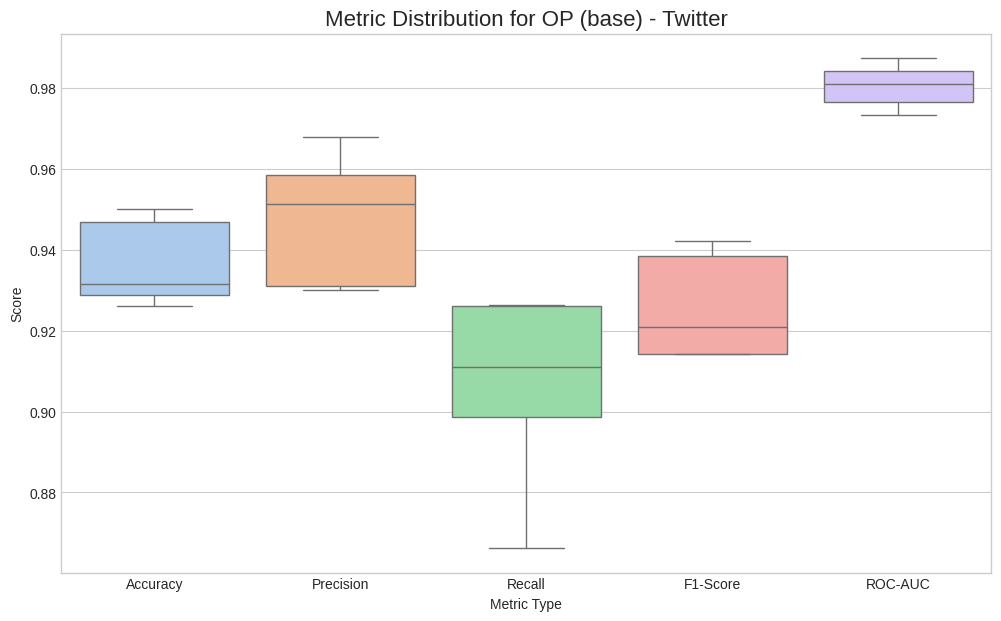

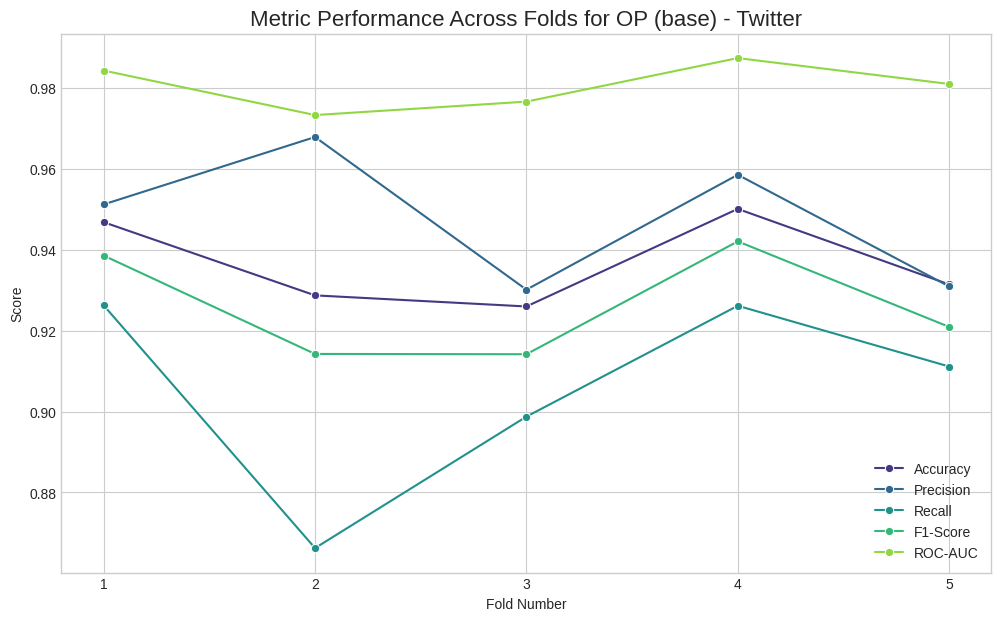

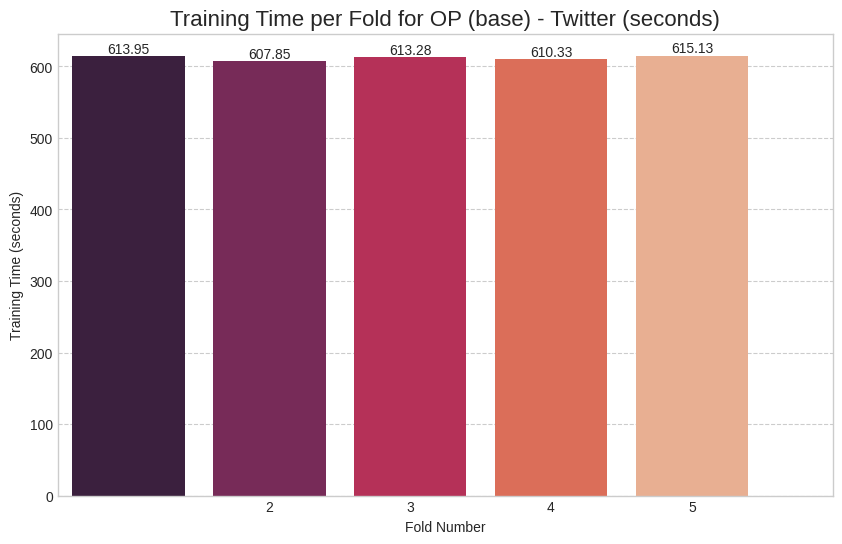

3329

In [ ]:
oldp_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model)
oldp_twitter_result['Variant'] = "OP (base)"
oldp_twitter_result['Dataset'] = 'Twitter'
all_results.append(oldp_twitter_result)
analyze_cv_results(oldp_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_twitter_result.csv'
oldp_twitter_result.to_csv(output_filename, index=False)
del output_filename
del oldp_twitter_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                  

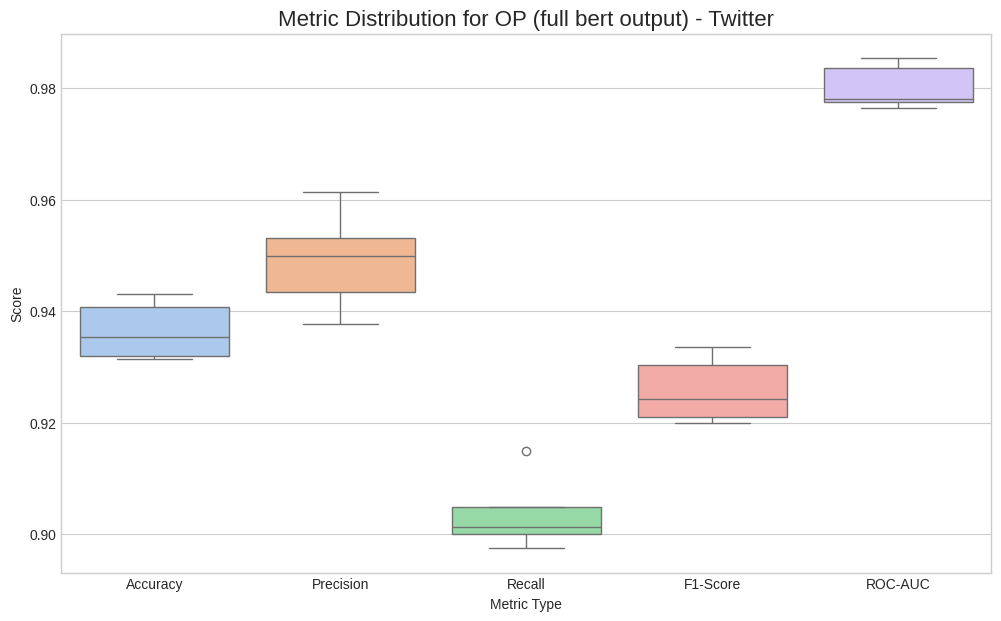

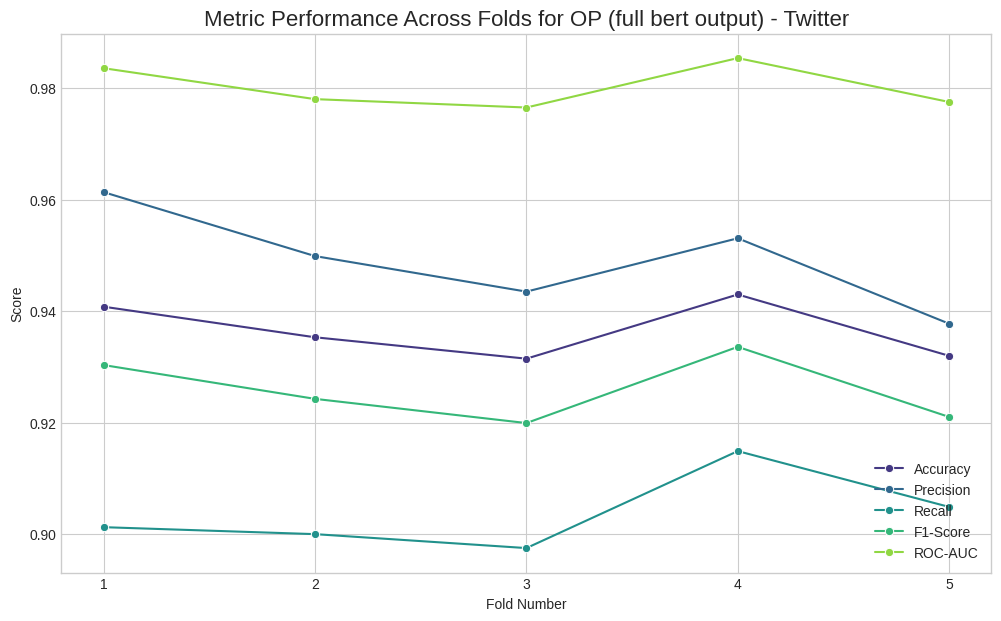

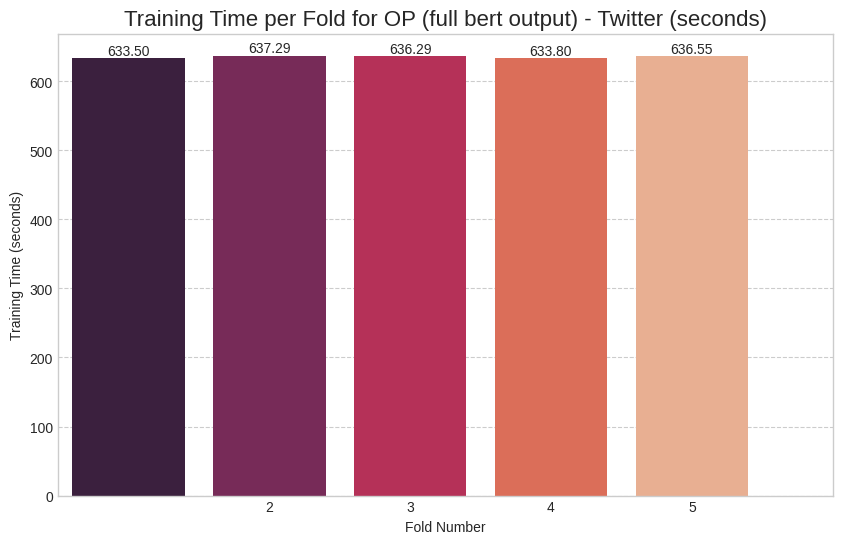

8227

In [ ]:
oldp_fb_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
oldp_fb_twitter_result['Variant'] = 'OP (full bert output)'
oldp_fb_twitter_result['Dataset'] = 'Twitter'
all_results.append(oldp_fb_twitter_result)
analyze_cv_results(oldp_fb_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_fb_twitter_result.csv'
oldp_fb_twitter_result.to_csv(output_filename, index=False)
del output_filename
del oldp_fb_twitter_result
gc.collect()

In [ ]:
## Use BERT as feature extraction
print("Loading TF-Hub models...")
preprocessor = hub.load(tfhub_handle_preprocess)
encoder = hub.load(tfhub_handle_encoder)
print("Models loaded.")

Loading TF-Hub models...
Models loaded.



 Starting BERT feature extraction...
Done
Embeddings shape: (9119, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_10 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_10 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout1

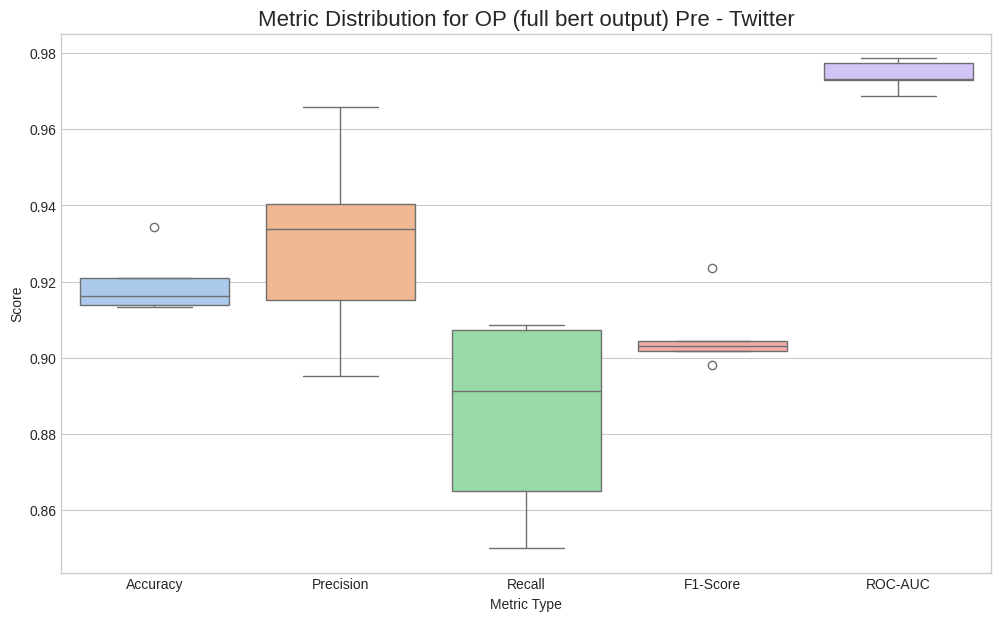

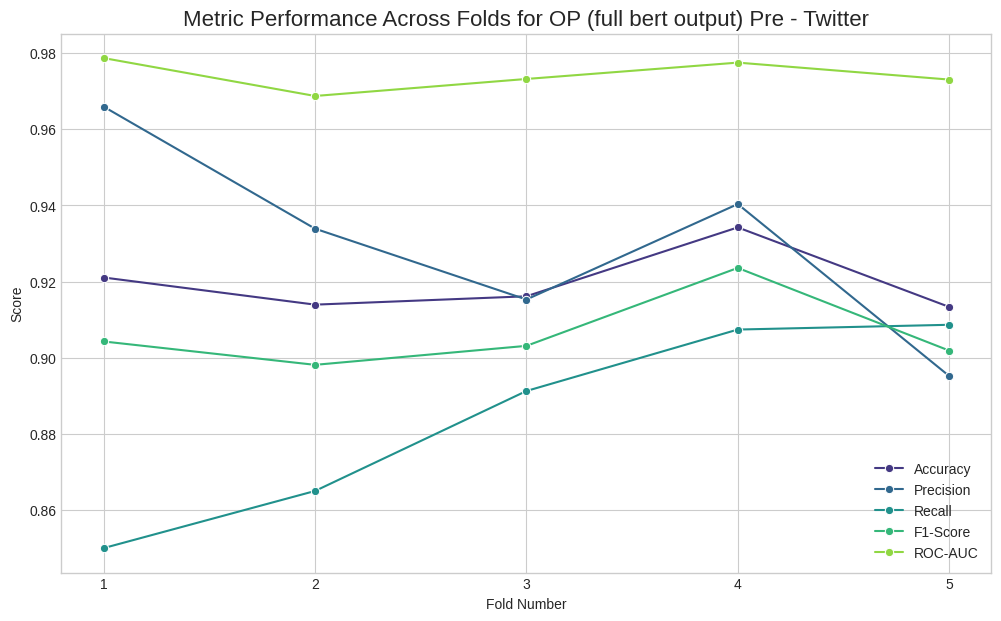

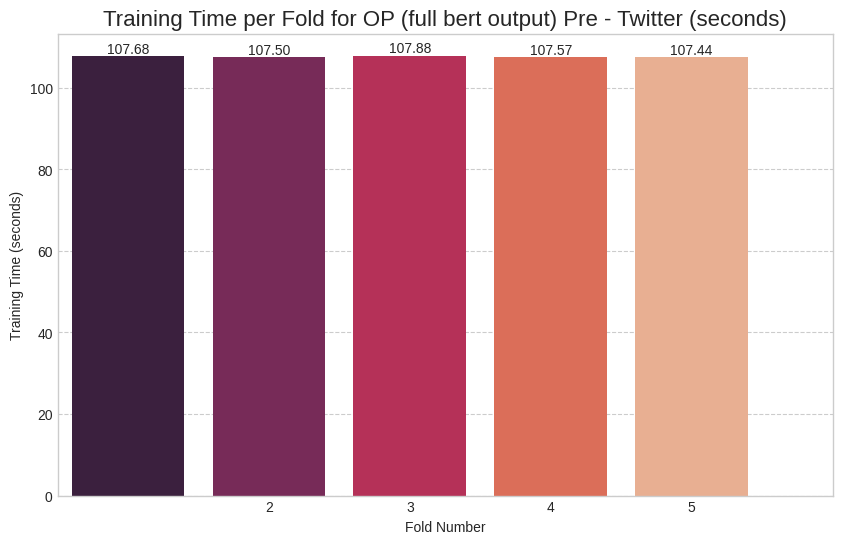

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

oldp_fb_pre_twitter_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
oldp_fb_pre_twitter_result['Variant'] = 'OP (full bert output) Pre'
oldp_fb_pre_twitter_result['Dataset'] = 'Twitter'
all_results.append(oldp_fb_pre_twitter_result)
analyze_cv_results(oldp_fb_pre_twitter_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_fb_pre_twitter_result.csv'
oldp_fb_pre_twitter_result.to_csv(output_filename, index=False)
del output_filename
del oldp_fb_pre_twitter_result
del X
del y
gc.collect()

In [ ]:
# DupNaN Preprocess Twitter
Twitter_path = "/content/twitter-suicidal_data.csv"
df_twitter = pd.read_csv(Twitter_path, encoding='latin-1')
df_twitter = df_twitter.rename(columns={'tweet': 'Text', 'intention': 'Label'})
df_twitter = preprocessing_new_rm_dupNaN(df_twitter)
print(df_twitter)

print(list(df_twitter['Label']).count(1), list(df_twitter['Label']).count(0))

X, y = data_preparation(df_twitter)
print(X)

del df_twitter
gc.collect()

Duplicates:
                                                   Text  Label
3401                                                         0
3924                                                         0
4304                                                         0
4391                                                         0
6207                                                         0
...                                                 ...    ...
8038  yuta hates reveluv i hate them so much when i ...      0
8041  yuta hates reveluv i hate them so much when i ...      0
8042  yuta hates reveluv i hate them so much when i ...      0
8250  yuta hates reveluv i hate them so much when i ...      0
8261  yuta hates reveluv i hate them so much when i ...      0

[409 rows x 2 columns]
                                                   Text  Label  \
0     my life is meaningless i just want to end my l...      1   
1     muttering i wanna die to myself daily for a fe...      1   
2     work

0

--- Starting Fold 1/5 ---
Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

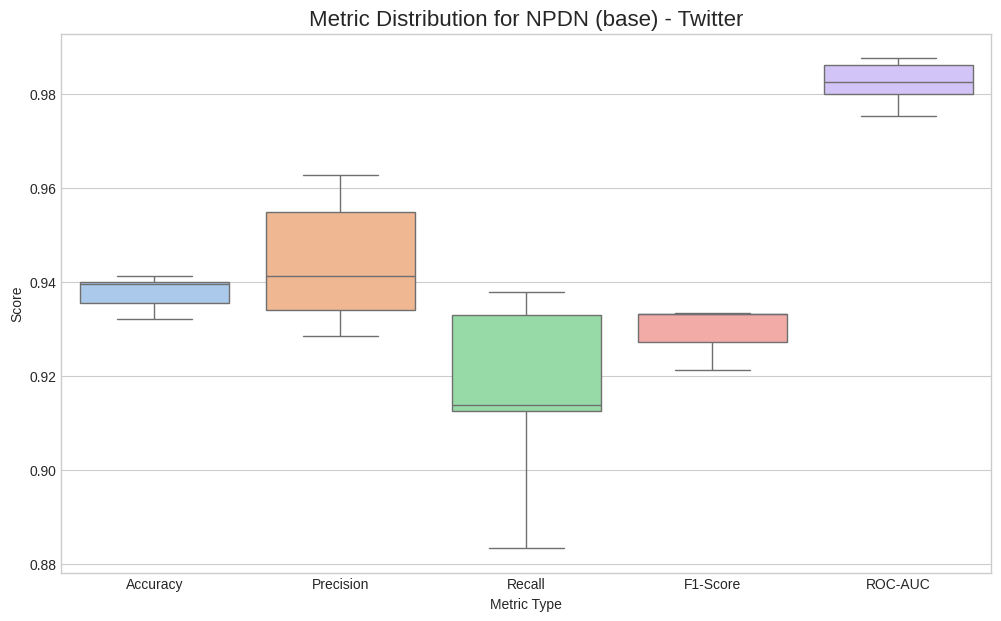

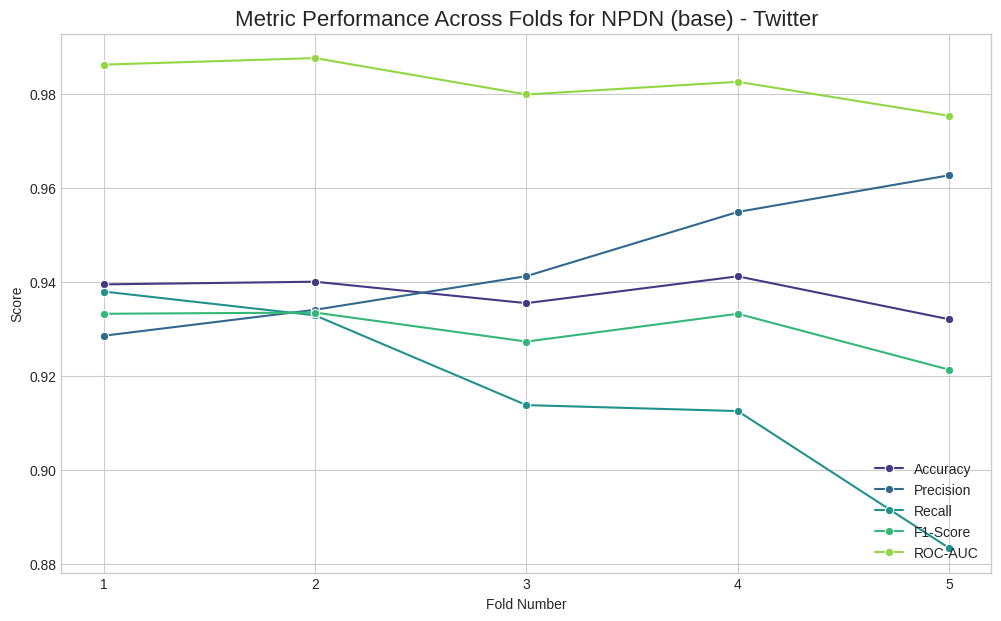

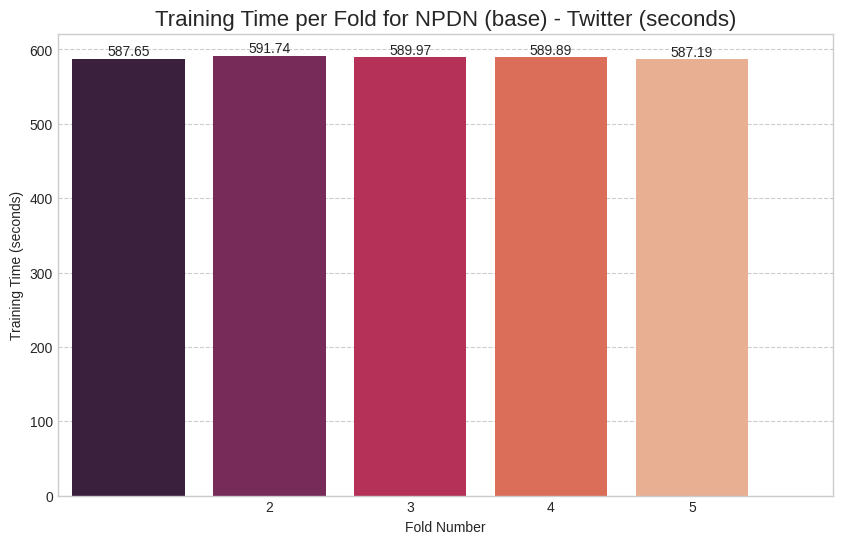

8330

In [ ]:
newdn_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model)
newdn_twitter_result['Variant'] = "NPDN (base)"
newdn_twitter_result['Dataset'] = 'Twitter'
all_results.append(newdn_twitter_result)
analyze_cv_results(newdn_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newdn_twitter_result.csv'
newdn_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newdn_twitter_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_20"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

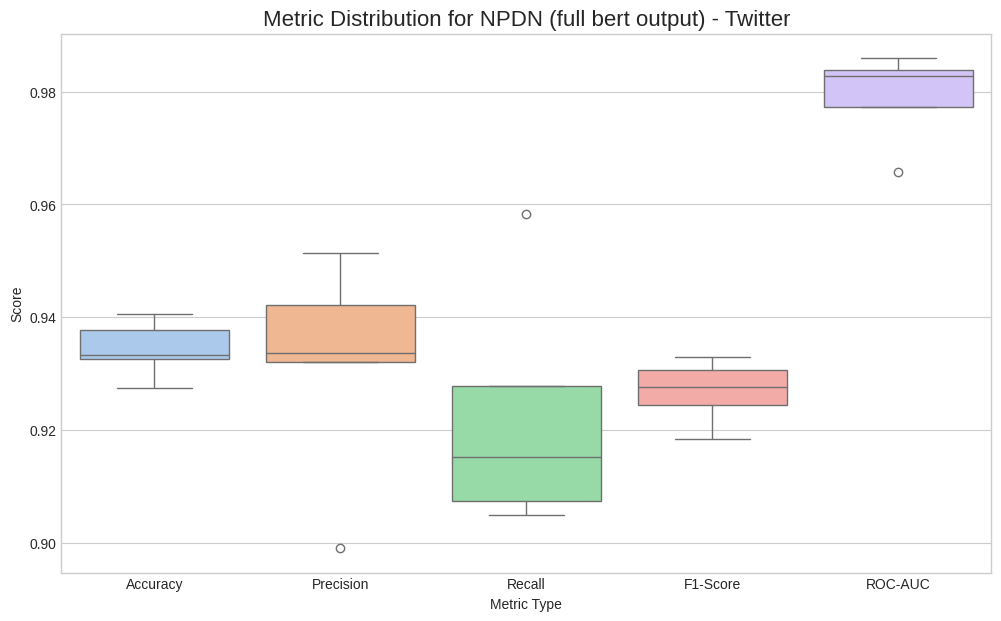

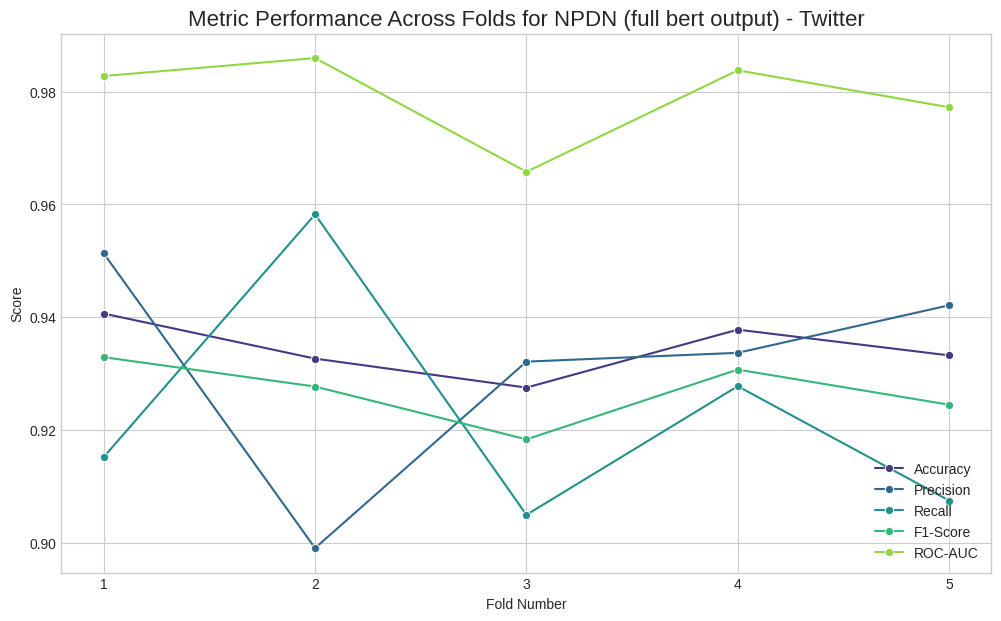

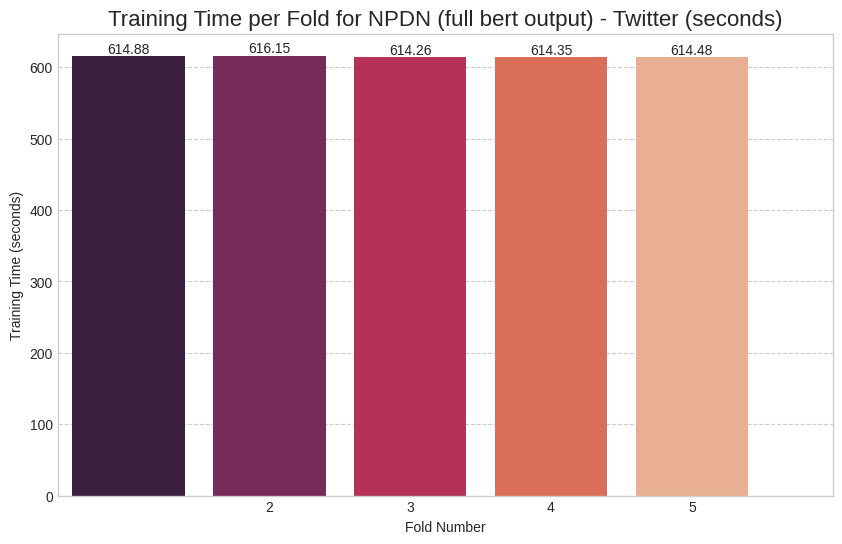

8227

In [ ]:
newdn_fb_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newdn_fb_twitter_result['Variant'] = 'NPDN (full bert output)'
newdn_fb_twitter_result['Dataset'] = 'Twitter'
all_results.append(newdn_fb_twitter_result)
analyze_cv_results(newdn_fb_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newdn_fb_twitter_result.csv'
newdn_fb_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newdn_fb_twitter_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (8760, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_25"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_25 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_25 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout1

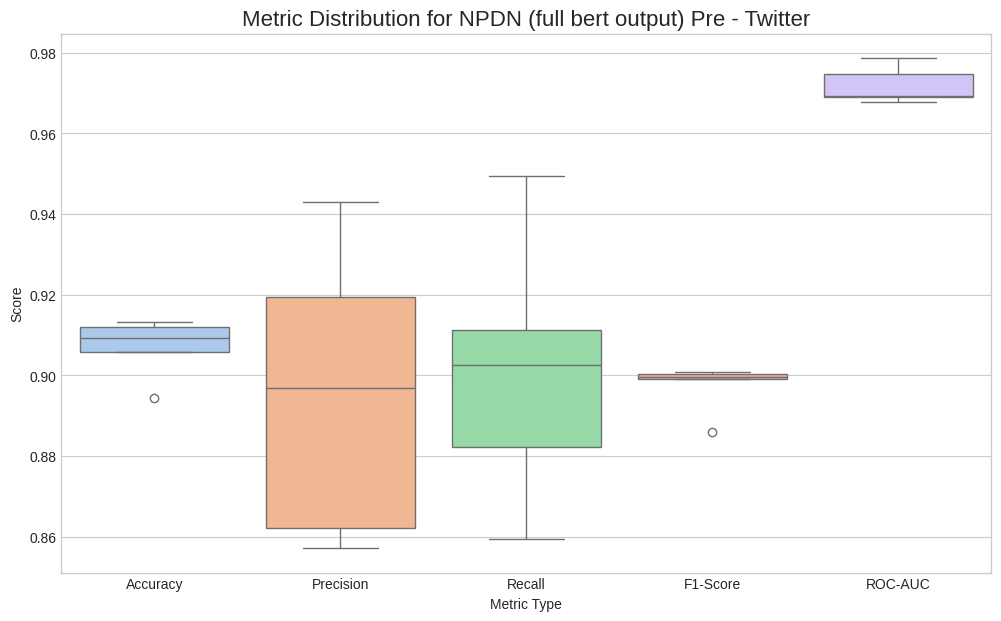

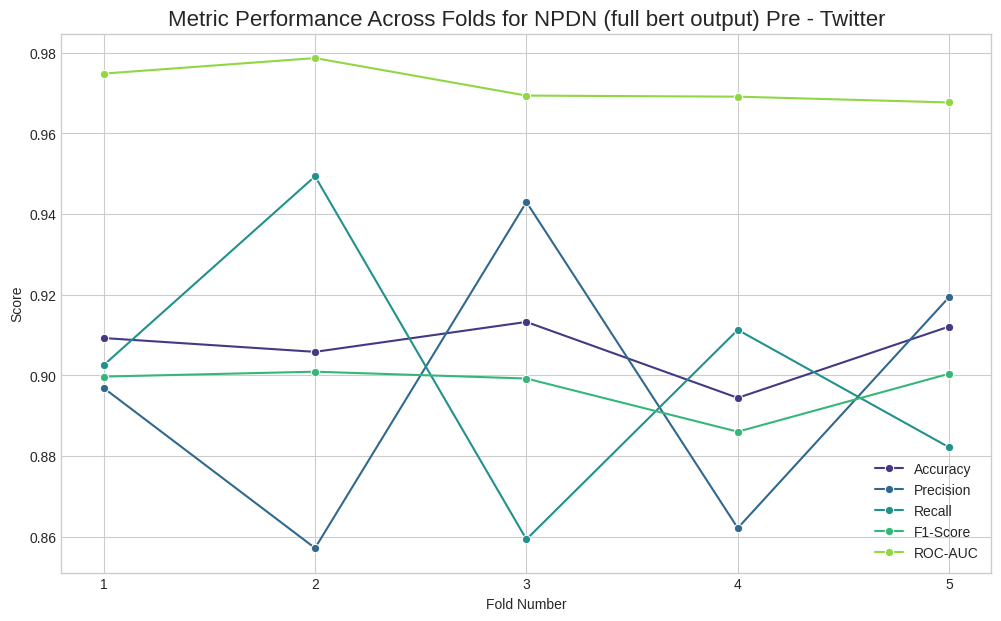

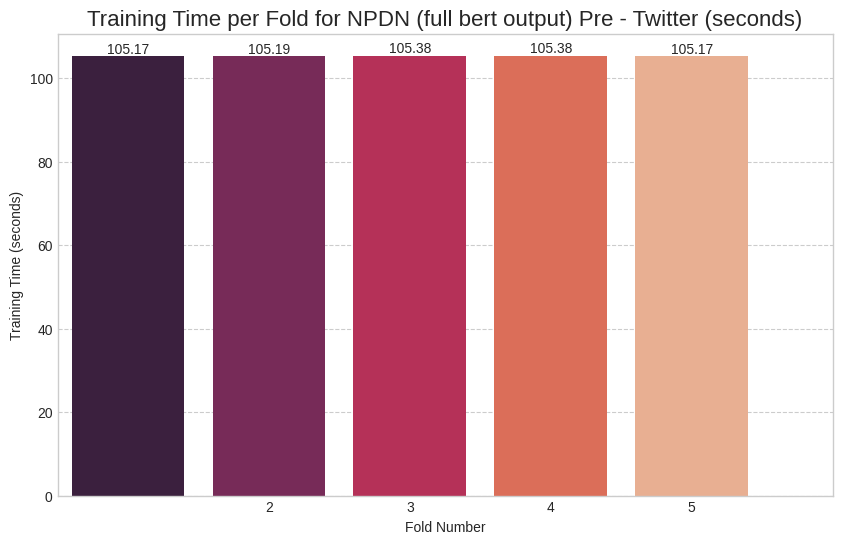

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

newdn_fb_pre_twitter_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
newdn_fb_pre_twitter_result['Variant'] = 'NPDN (full bert output) Pre'
newdn_fb_pre_twitter_result['Dataset'] = 'Twitter'
all_results.append(newdn_fb_pre_twitter_result)
analyze_cv_results(newdn_fb_pre_twitter_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/newdn_fb_pre_twitter_result.csv'
newdn_fb_pre_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newdn_fb_pre_twitter_result
del X
del y
gc.collect()

In [ ]:
# New Preprocess Twitter
Twitter_path = "/content/twitter-suicidal_data.csv"
df_twitter = pd.read_csv(Twitter_path, encoding='latin-1')
df_twitter = df_twitter.rename(columns={'tweet': 'Text', 'intention': 'Label'})
df_twitter = preprocessing_new(df_twitter)
print(df_twitter)

print(list(df_twitter['Label']).count(1), list(df_twitter['Label']).count(0))

X, y = data_preparation(df_twitter)
print(X)

del df_twitter
gc.collect()

Duplicates:
                                                   Text  Label  \
3401                                                         0   
3849                                                         0   
3924                                                         0   
4258                                                         0   
4304                                                         0   
...                                                 ...    ...   
8038  yuta hates reveluv hate much see want die feel...      0   
8041  yuta hates reveluv hate much see want die feel...      0   
8042  yuta hates reveluv hate much see want die feel...      0   
8250  yuta hates reveluv hate much see want die feel...      0   
8261  yuta hates reveluv hate much see want die feel...      0   

                                                 Tokens  Length  
3401                                                 []       0  
3849                                                 []       0

0

--- Starting Fold 1/5 ---
Model: "model_30"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

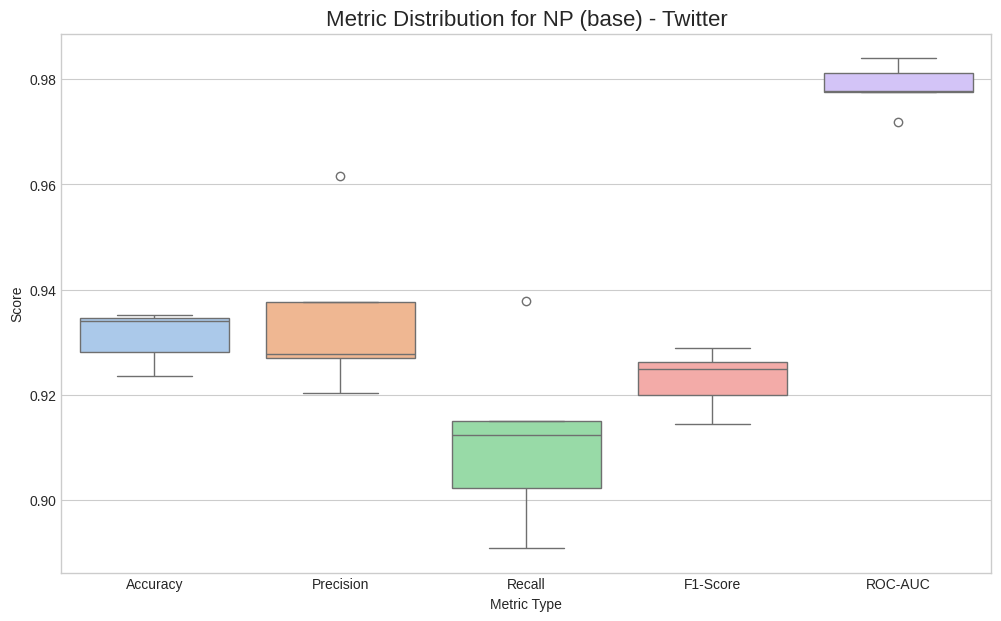

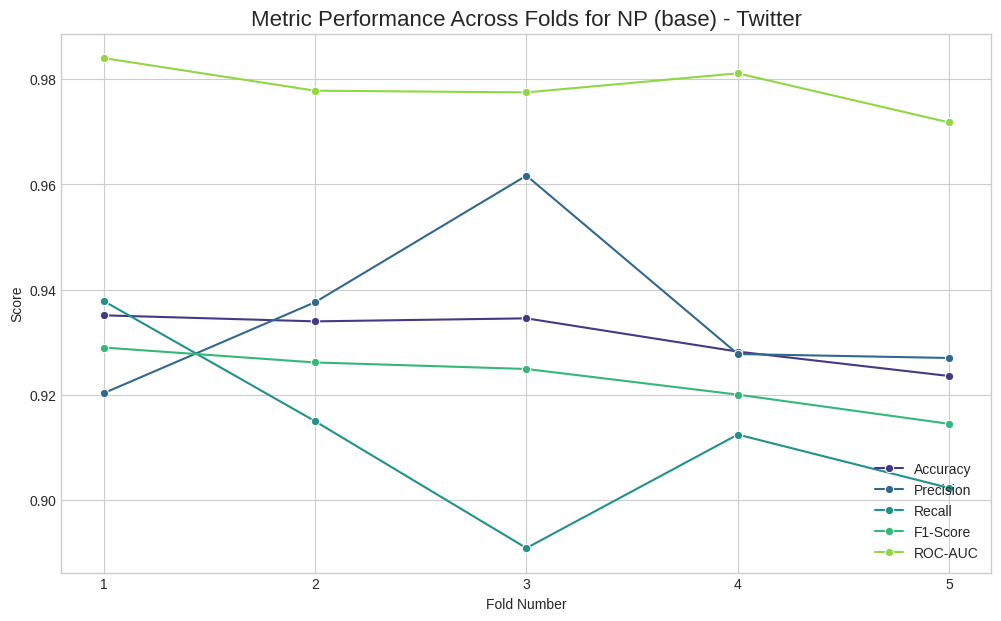

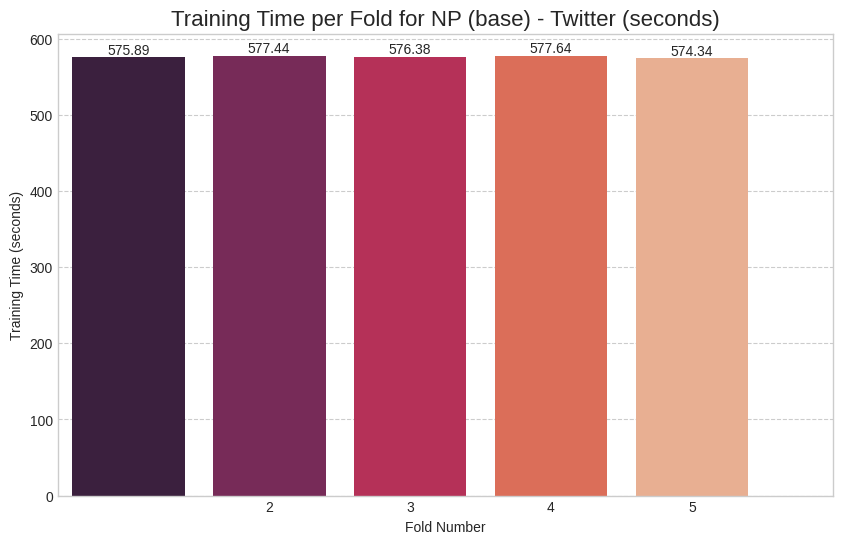

8227

In [ ]:
newp_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model)
newp_twitter_result['Variant'] = "NP (base)"
newp_twitter_result['Dataset'] = 'Twitter'
all_results.append(newp_twitter_result)
analyze_cv_results(newp_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_twitter_result.csv'
newp_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newp_twitter_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_35"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

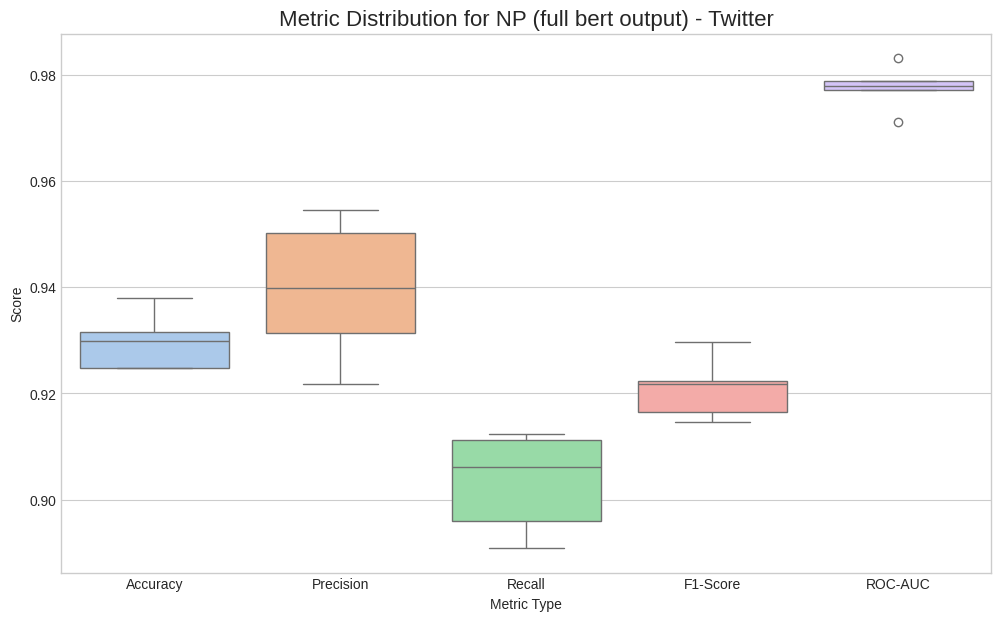

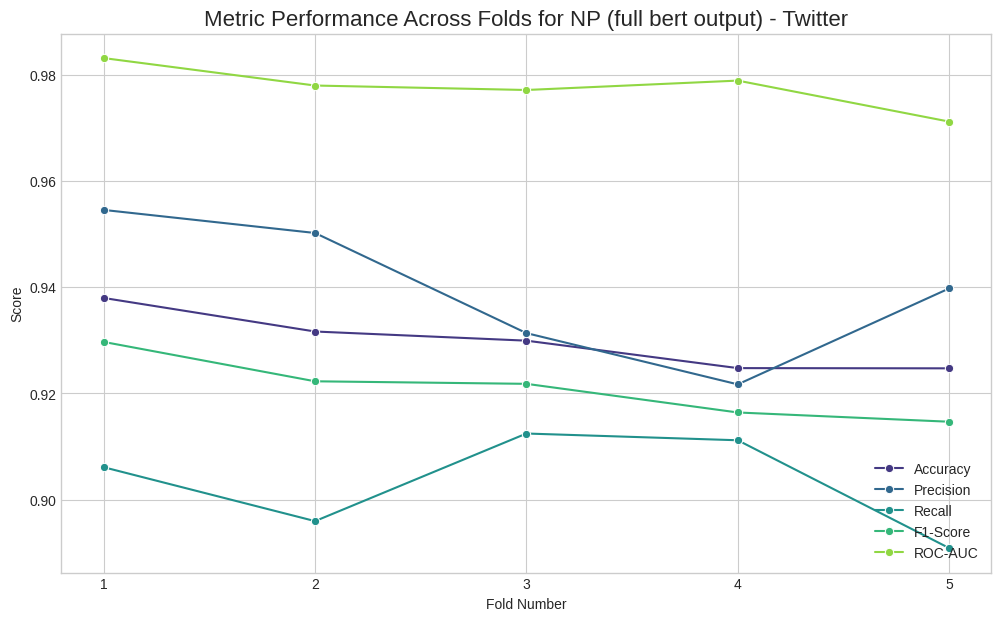

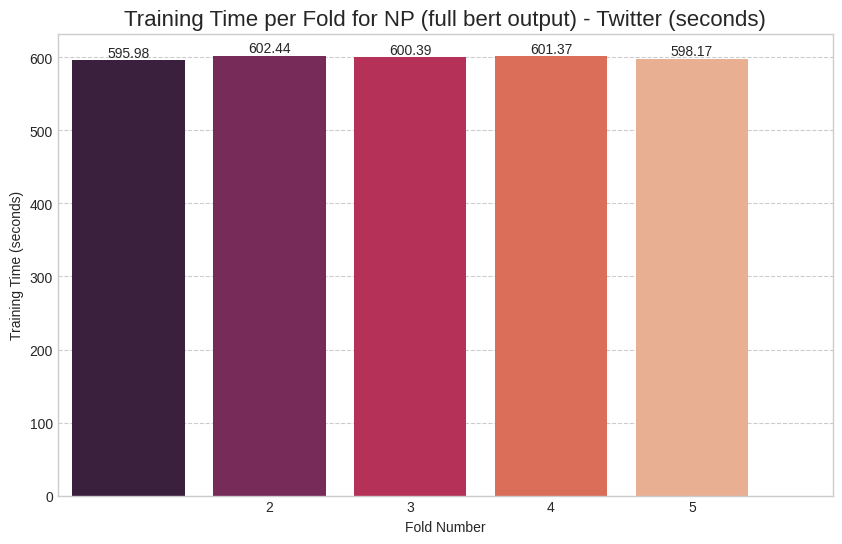

8227

In [ ]:
newp_fb_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newp_fb_twitter_result['Variant'] = 'NP (full bert output)'
newp_fb_twitter_result['Dataset'] = 'Twitter'
all_results.append(newp_fb_twitter_result)
analyze_cv_results(newp_fb_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_fb_twitter_result.csv'
newp_fb_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newp_fb_twitter_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (8704, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_40"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_40 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_40 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout1

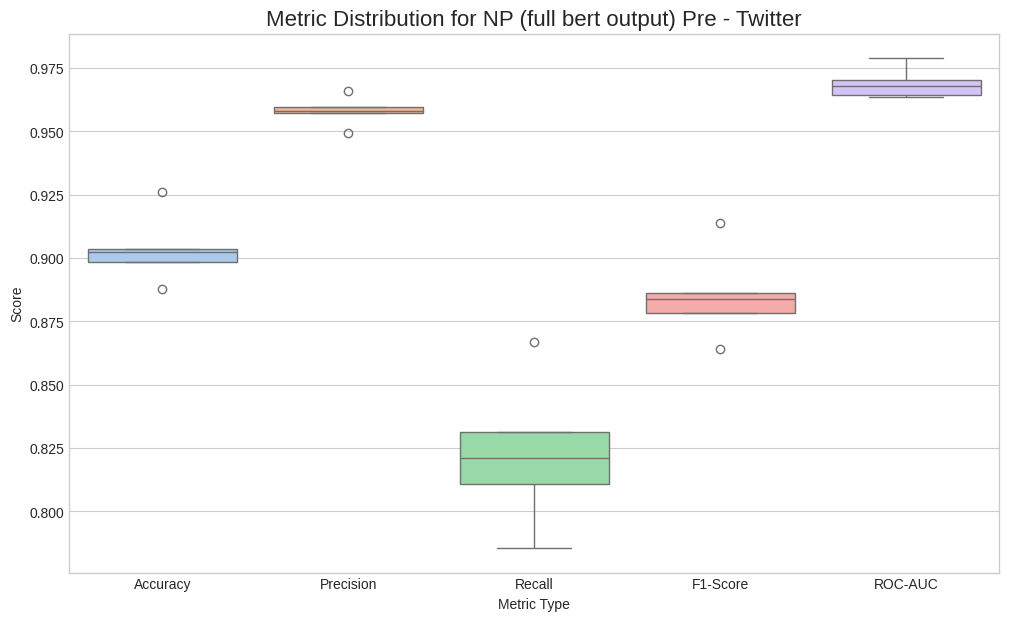

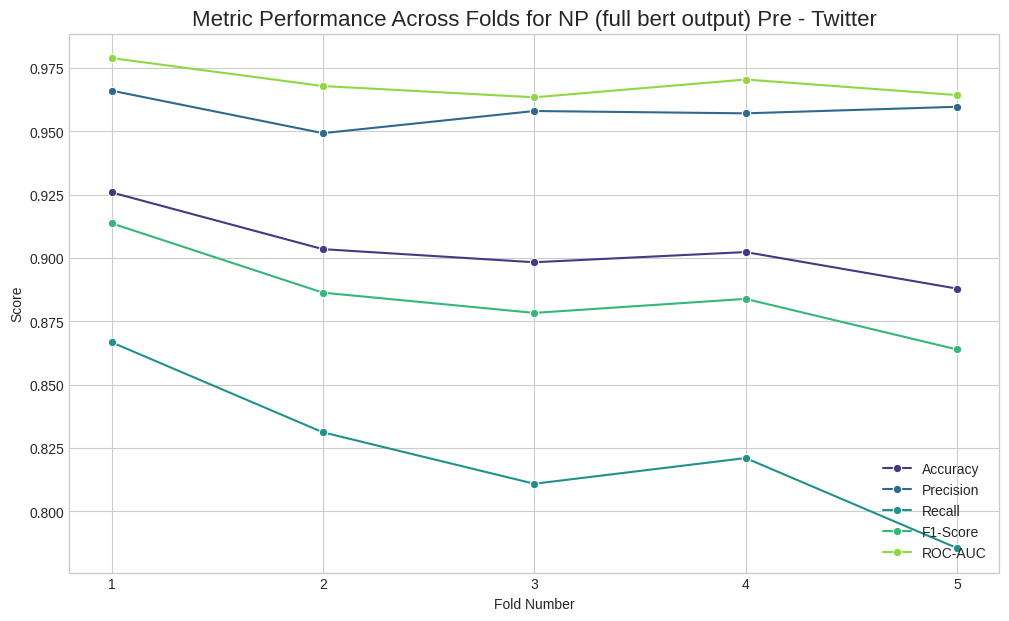

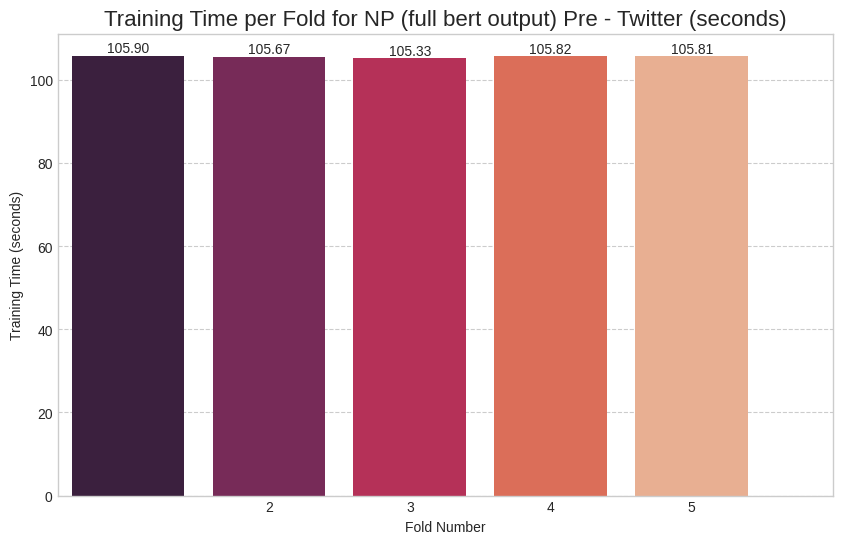

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

newp_fb_pre_twitter_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
newp_fb_pre_twitter_result['Variant'] = 'NP (full bert output) Pre'
newp_fb_pre_twitter_result['Dataset'] = 'Twitter'
all_results.append(newp_fb_pre_twitter_result)
analyze_cv_results(newp_fb_pre_twitter_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_fb_pre_twitter_result.csv'
newp_fb_pre_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newp_fb_pre_twitter_result
del X
del y
gc.collect()

In [ ]:
# New Preprocess Remove Stopword and NaN only (exclude dup) Twitter
Twitter_path = "/content/twitter-suicidal_data.csv"
df_twitter = pd.read_csv(Twitter_path, encoding='latin-1')
df_twitter = df_twitter.rename(columns={'tweet': 'Text', 'intention': 'Label'})
df_twitter = preprocessing_new_rm_stop_NaN(df_twitter)
print(df_twitter)

print(list(df_twitter['Label']).count(1), list(df_twitter['Label']).count(0))

X, y = data_preparation(df_twitter)
print(X)

del df_twitter
gc.collect()

                                                   Text  Label  \
0     life meaningless want end life badly life comp...      1   
1     muttering wan na die daily months feel worthle...      1   
2     work slave really feel like purpose life make ...      1   
3     something 2 october overdosed felt alone horri...      1   
4     feel like one cares want die maybe feel less l...      1   
...                                                 ...    ...   
9114  ever laid bed night cried good enough counted ...      1   
9115  fault blame pain still alone inside broken hom...      1   
9116  stop asking trust still coughing water last ti...      1   
9117  never know handle sadness crying makes feel st...      1   
9118  cancer takes life blame cancer depression dise...      1   

                                                 Tokens  Length  
0     [life, meaningless, want, end, life, badly, li...      42  
1     [muttering, wan, na, die, daily, months, feel,...      22  
2     [wo

0

--- Starting Fold 1/5 ---
Model: "model_45"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

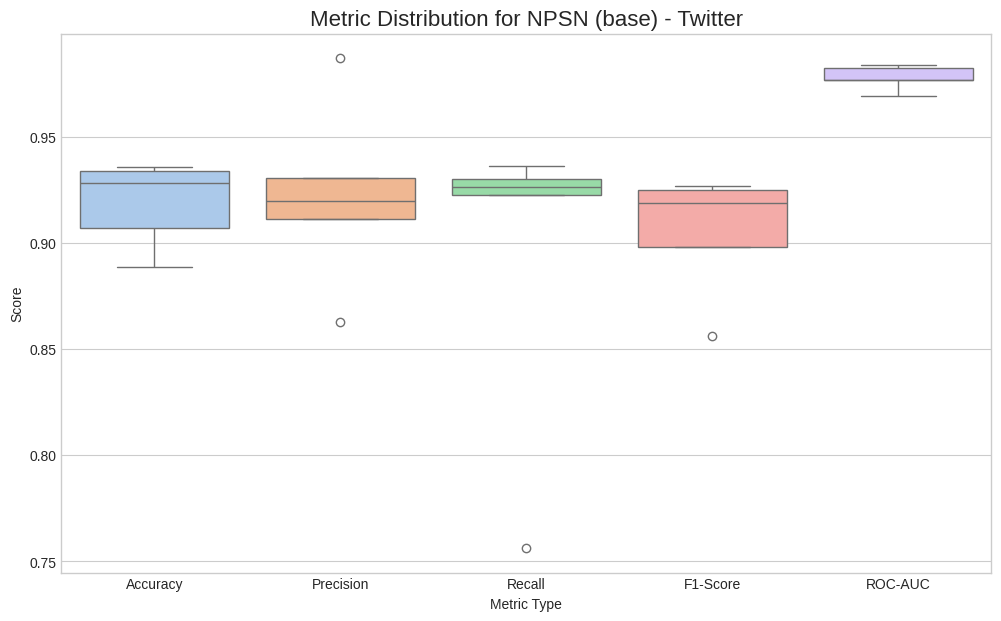

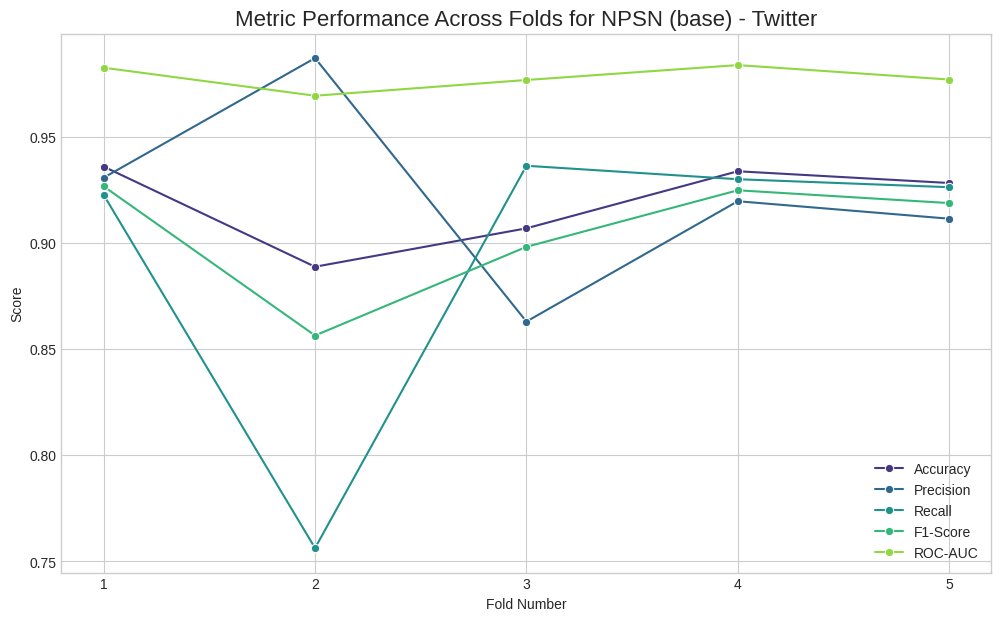

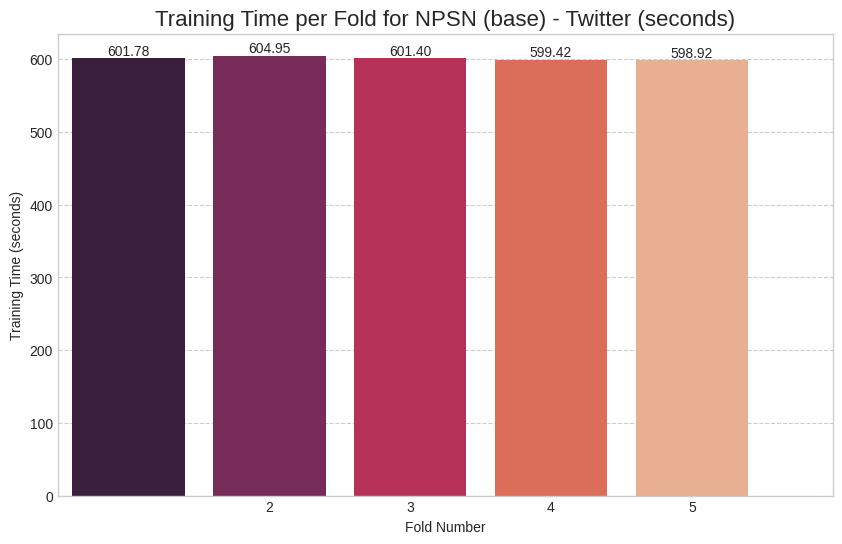

8227

In [ ]:
newpSN_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model)
newpSN_twitter_result['Variant'] = "NPSN (base)"
newpSN_twitter_result['Dataset'] = 'Twitter'
all_results.append(newpSN_twitter_result)
analyze_cv_results(newpSN_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_twitter_result.csv'
newpSN_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_twitter_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

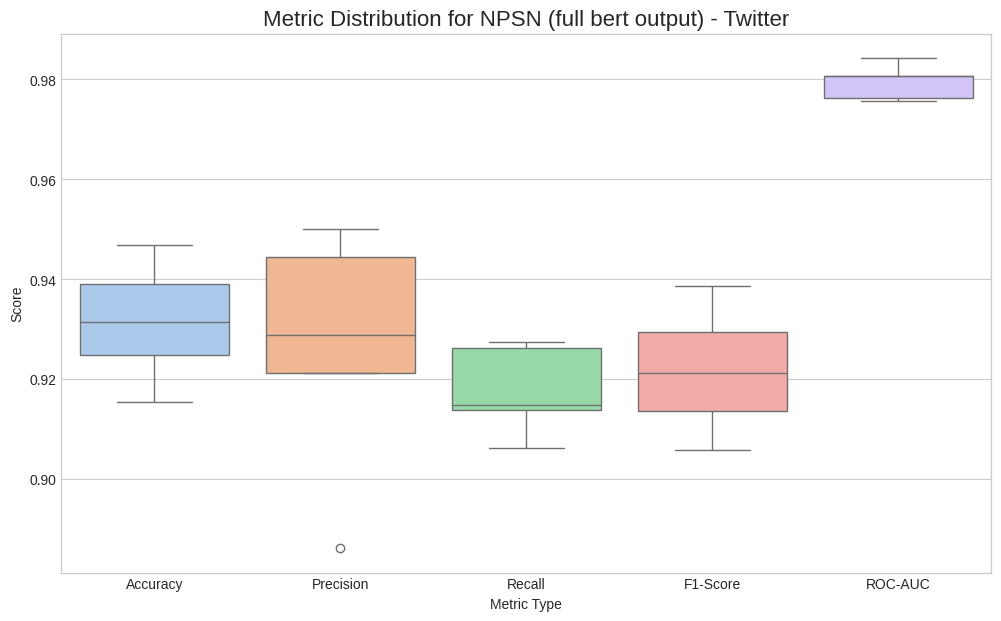

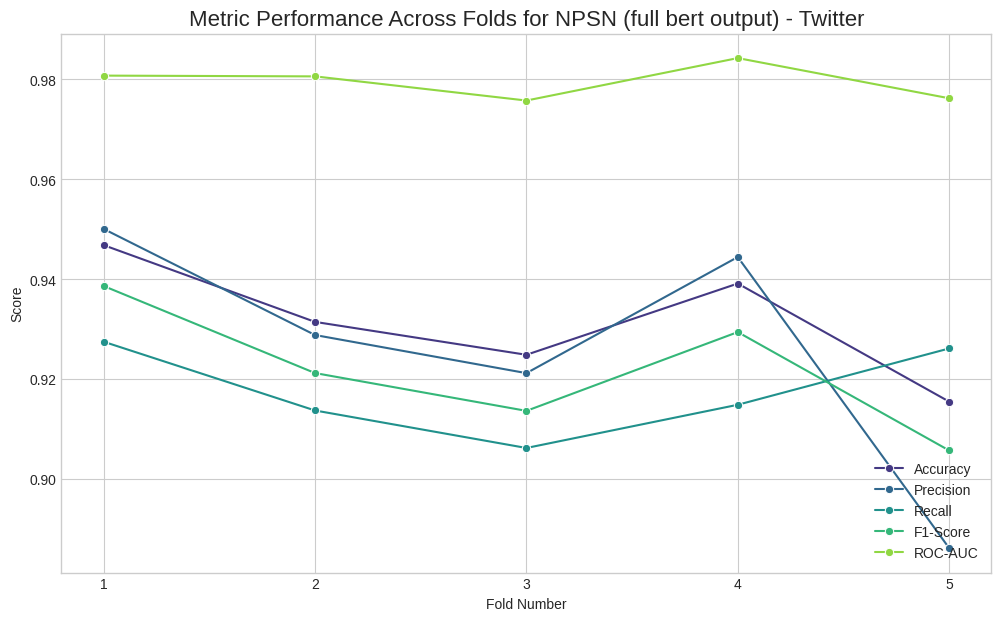

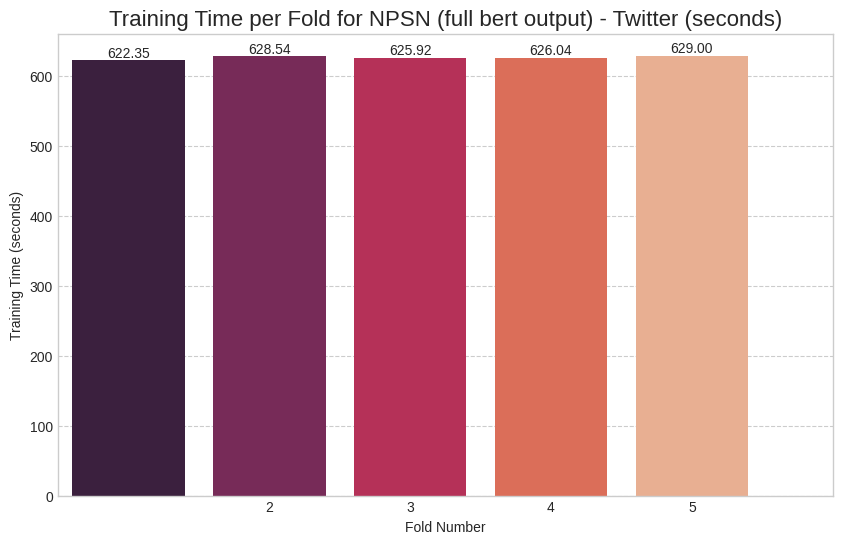

8227

In [ ]:
newpSN_fb_twitter_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newpSN_fb_twitter_result['Variant'] = 'NPSN (full bert output)'
newpSN_fb_twitter_result['Dataset'] = 'Twitter'
all_results.append(newpSN_fb_twitter_result)
analyze_cv_results(newpSN_fb_twitter_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_fb_twitter_result.csv'
newpSN_fb_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_fb_twitter_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (9119, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_55"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_55 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_55 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout1

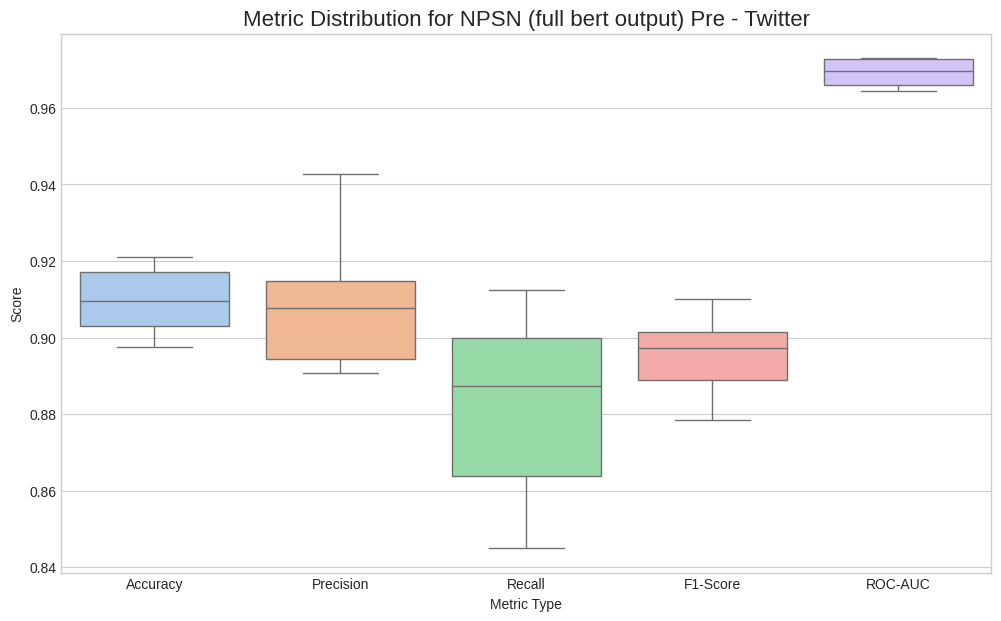

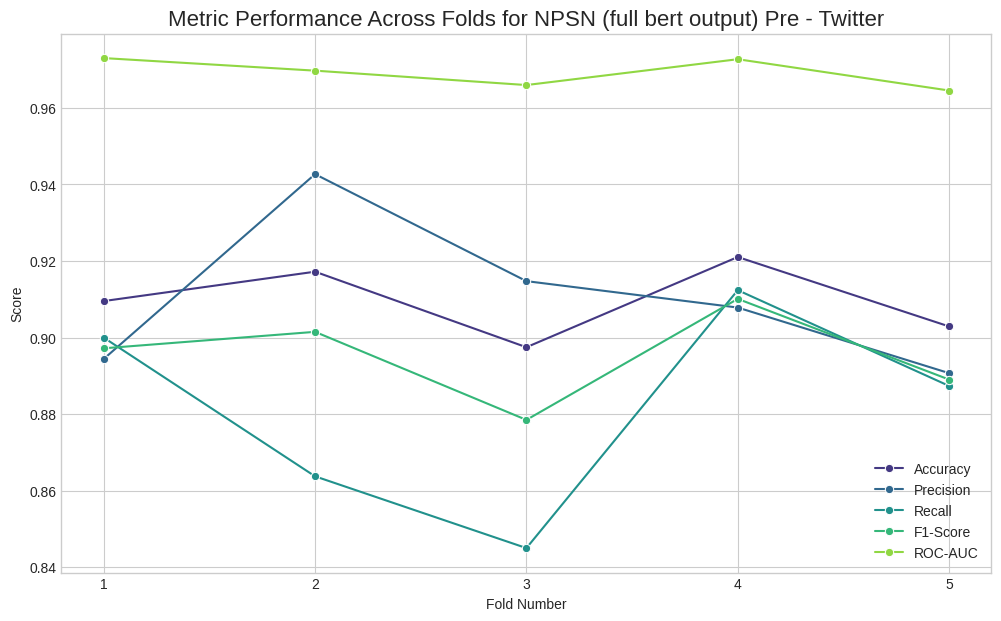

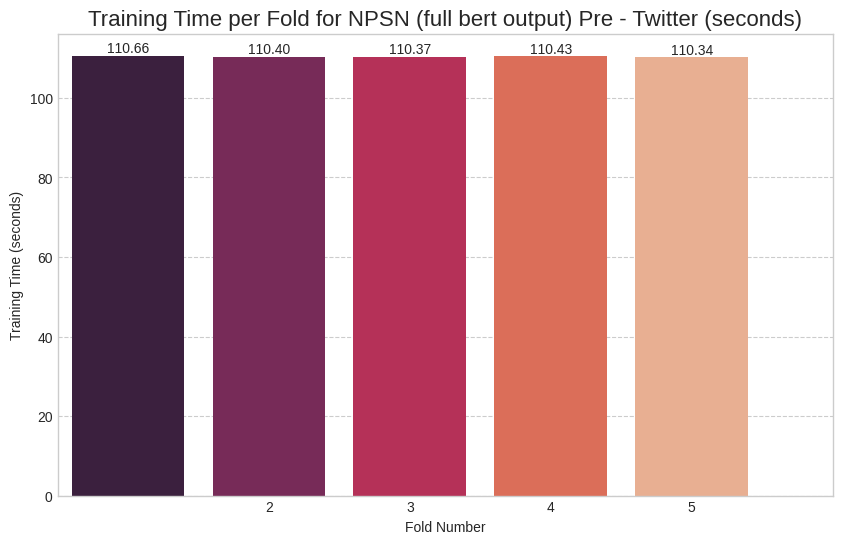

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

newpSN_fb_pre_twitter_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
newpSN_fb_pre_twitter_result['Variant'] = 'NPSN (full bert output) Pre'
newpSN_fb_pre_twitter_result['Dataset'] = 'Twitter'
all_results.append(newpSN_fb_pre_twitter_result)
analyze_cv_results(newpSN_fb_pre_twitter_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_fb_pre_twitter_result.csv'
newpSN_fb_pre_twitter_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_fb_pre_twitter_result
del X
del y
gc.collect()

In [ ]:
def analyze_model_performance(all_results_list):
    """
    Analyzes and visualizes the performance of model variants from a list of result DataFrames.

    Args:
        all_results_list (list): A list of pandas DataFrames, each containing the results
                                 of a cross-validation run for a specific model variant.
    """
    all_results = pd.concat(all_results_list, ignore_index=True)
    print(all_results)
    # --- Summary Statistics ---
    print("--- Summary Statistics (Mean and Standard Deviation) ---")
    summary_stats = all_results.groupby(['Dataset', 'Variant']).agg({
        'Accuracy': ['mean', 'std'],
        'Precision': ['mean', 'std'],
        'Recall': ['mean', 'std'],
        'F1-Score': ['mean', 'std'],
        'ROC-AUC': ['mean','std'],
        'Training Time (s)': ['mean', 'std']
    })
    print(tabulate(summary_stats, headers='keys', tablefmt='psql'))
    print("\n" + "="*80 + "\n")

    # --- Total Training Time Statistics ---
    print("--- Total Training Time per Variant ---")
    total_time_stats = all_results.groupby(['Dataset', 'Variant'])['Training Time (s)'].sum().reset_index()
    total_time_stats = total_time_stats.rename(columns={'Training Time (s)': 'Total Training Time (s)'})
    print(tabulate(total_time_stats, headers='keys', tablefmt='psql', showindex=False))
    print("\n" + "="*80 + "\n")

    datasets = all_results['Dataset'].unique()
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)']

    for dataset in datasets:
        print(f"--- Analysis for {dataset} Dataset ---")
        dataset_results = all_results[all_results['Dataset'] == dataset]

        # --- Line Plots ---
        print(f"\n--- Line Plots for {dataset} Dataset ---")
        for metric in metrics:
            plt.figure(figsize=(15, 8))
            sns.lineplot(data=dataset_results, x='Fold', y=metric, hue='Variant', marker='o')
            plt.title(f'Line Plot of {metric} for {dataset} Dataset')
            plt.ylabel(metric)
            plt.xlabel('Fold')
            plt.grid(True)
            plt.legend(loc='lower right')
            plt.show()
            print("")

        # --- Box Plots ---
        print(f"\n--- Box Plots for {dataset} Dataset ---")
        for metric in metrics:
            plt.figure(figsize=(15, 8))
            sns.boxplot(data=dataset_results, x='Variant', y=metric)
            plt.title(f'Box Plot of {metric} for {dataset} Dataset')
            plt.ylabel(metric)
            plt.xlabel('Variant')
            plt.xticks(rotation=15)
            plt.grid(True)
            plt.show()
            print("")

        print("\n" + "="*80 + "\n")

    # --- Overall Bar Charts for Training Time ---
    print(f"\n--- Overall Bar Charts for Training Time Comparison ---")

    # --- Bar Chart for Mean Training Time ---
    mean_time_stats = summary_stats['Training Time (s)']['mean'].reset_index()
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(data=mean_time_stats, x='Variant', y='mean', hue='Dataset', dodge=True)
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title('Mean Training Time per Fold (Twitter Datasets)')
    plt.ylabel('Mean Training Time (s)')
    plt.xlabel('Variant')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.show()
    print("")

    # --- Bar Chart for Total Training Time ---
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(data=total_time_stats, x='Variant', y='Total Training Time (s)', hue='Dataset', dodge=True)
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title('Total Training Time (Twitter Datasets)')
    plt.ylabel('Total Training Time (s)')
    plt.xlabel('Variant')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.show()

    return summary_stats

    Fold  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0      1  0.946820   0.951220  0.926250  0.938569  0.984312   
1      2  0.928728   0.967877  0.866250  0.914248  0.973312   
2      3  0.925987   0.930142  0.898750  0.914177  0.976631   
3      4  0.950110   0.958549  0.926158  0.942075  0.987396   
4      5  0.931432   0.930946  0.911139  0.920936  0.980993   
5      1  0.940789   0.961333  0.901250  0.930323  0.983563   
6      2  0.935307   0.949868  0.900000  0.924262  0.978018   
7      3  0.931469   0.943495  0.897500  0.919923  0.976516   
8      4  0.942982   0.953064  0.914894  0.933589  0.985381   
9      5  0.931980   0.937743  0.904881  0.921019  0.977506   
10     1  0.921053   0.965909  0.850000  0.904255  0.978671   
11     2  0.913925   0.933873  0.865000  0.898118  0.968718   
12     3  0.916118   0.915276  0.891250  0.903103  0.973186   
13     4  0.934211   0.940337  0.907384  0.923567  0.977481   
14     5  0.913330   0.895191  0.908636  0.901863  0.97

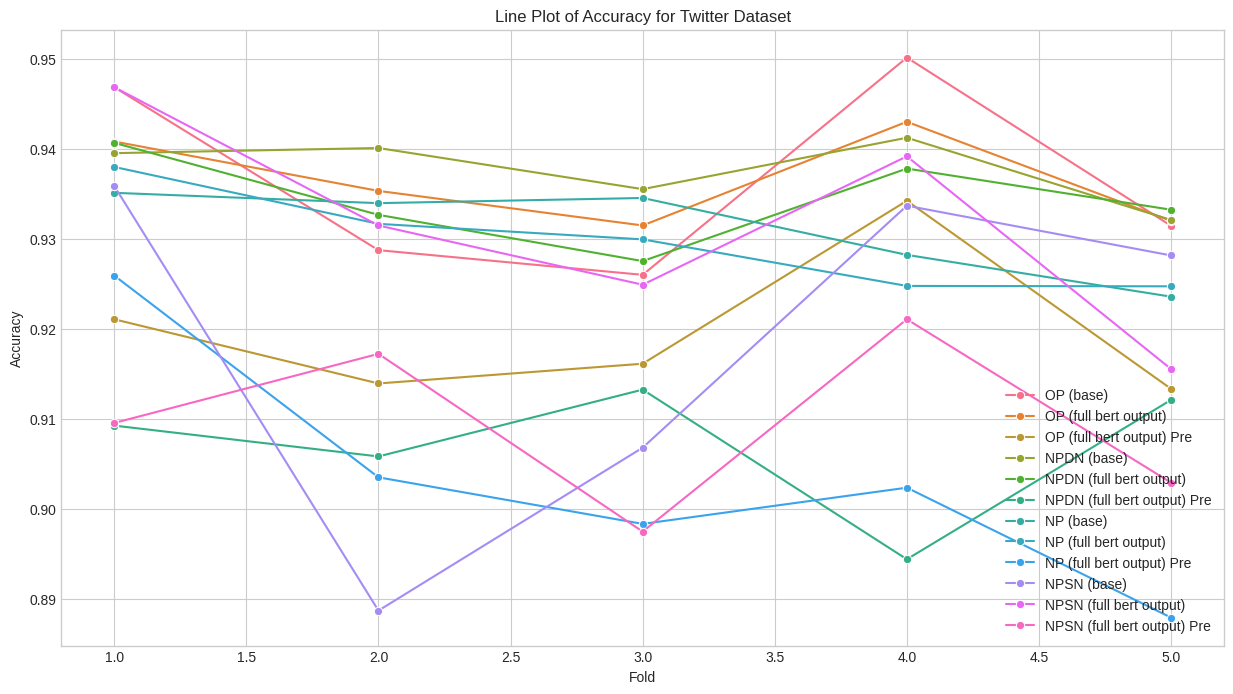

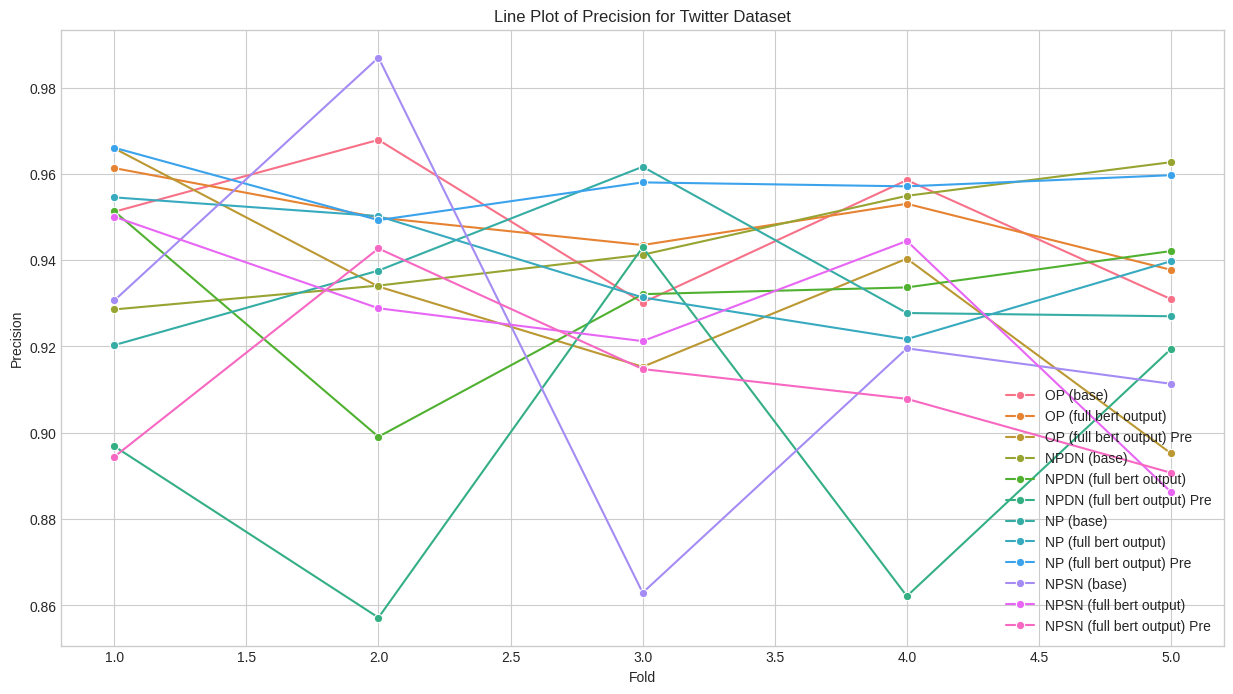

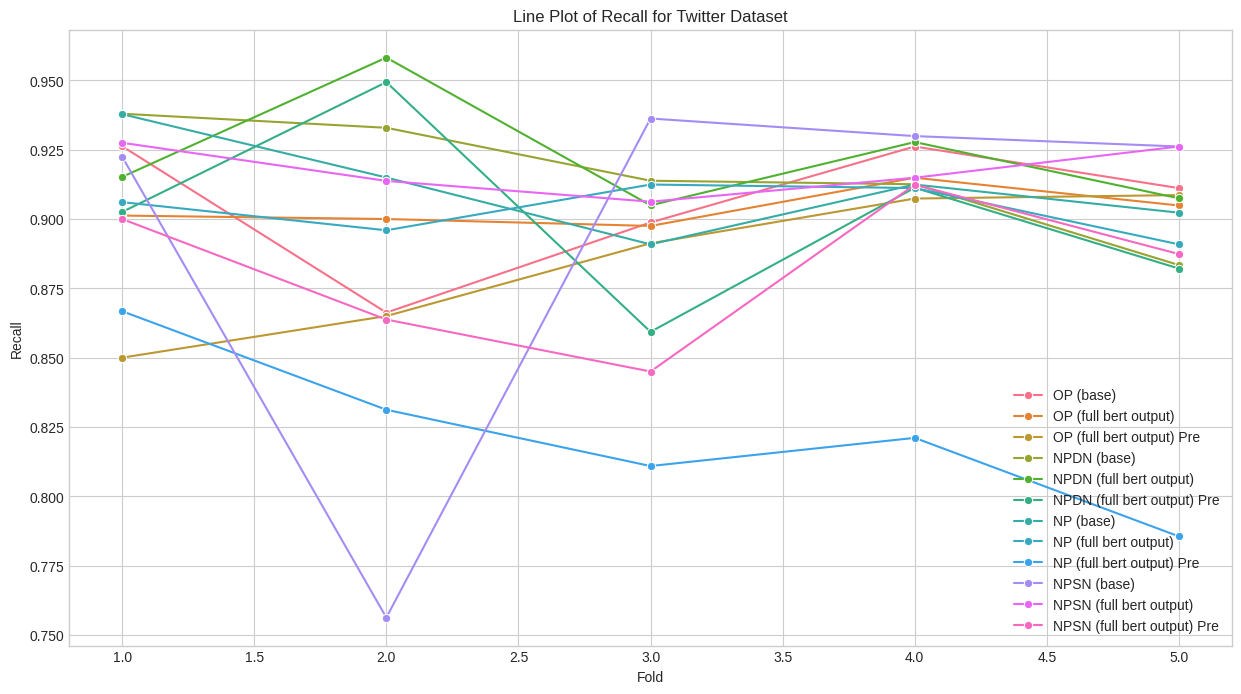

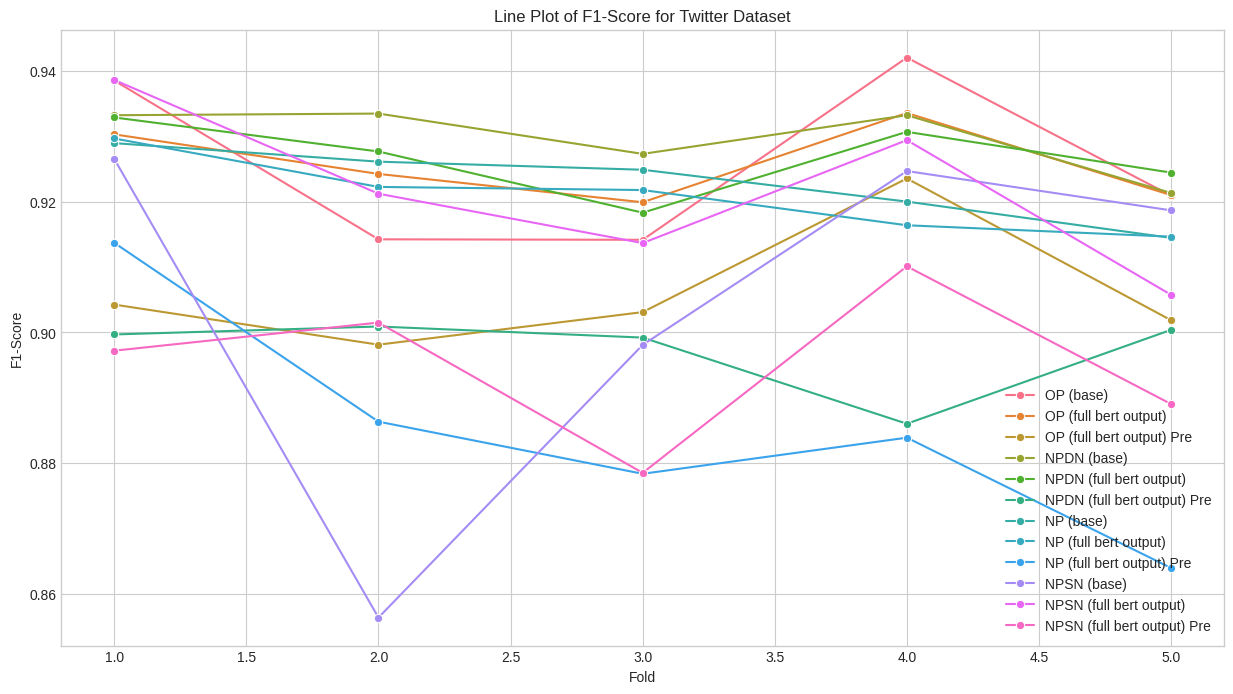

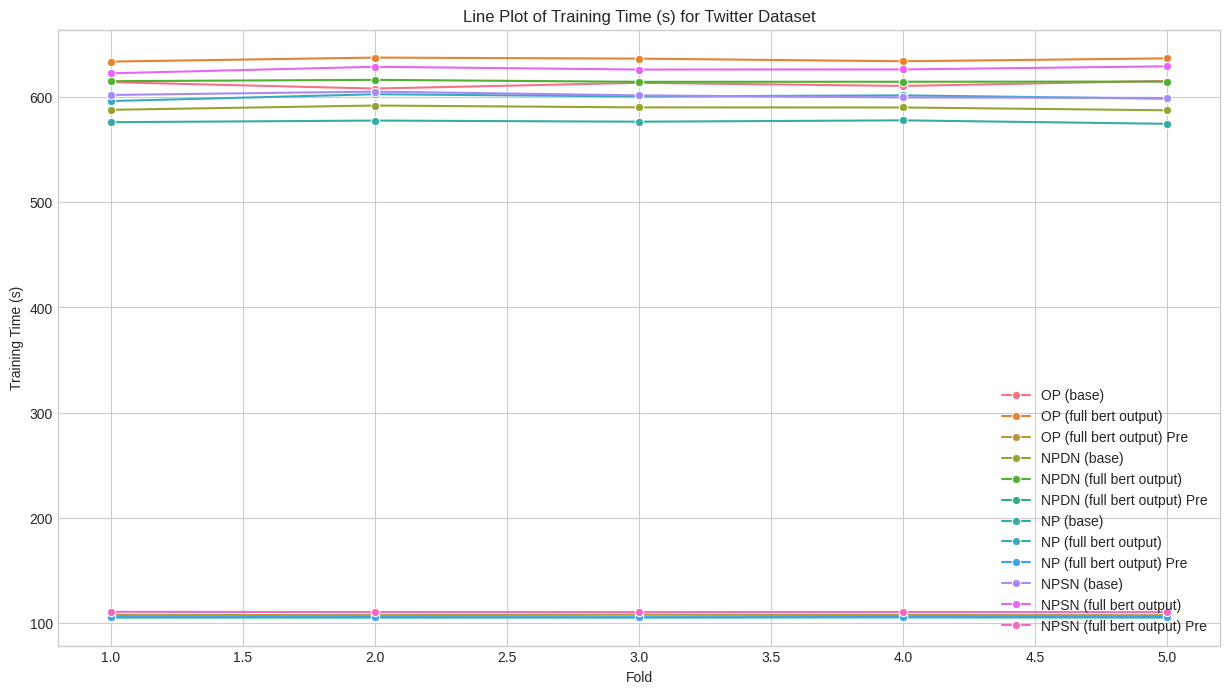



--- Box Plots for Twitter Dataset ---


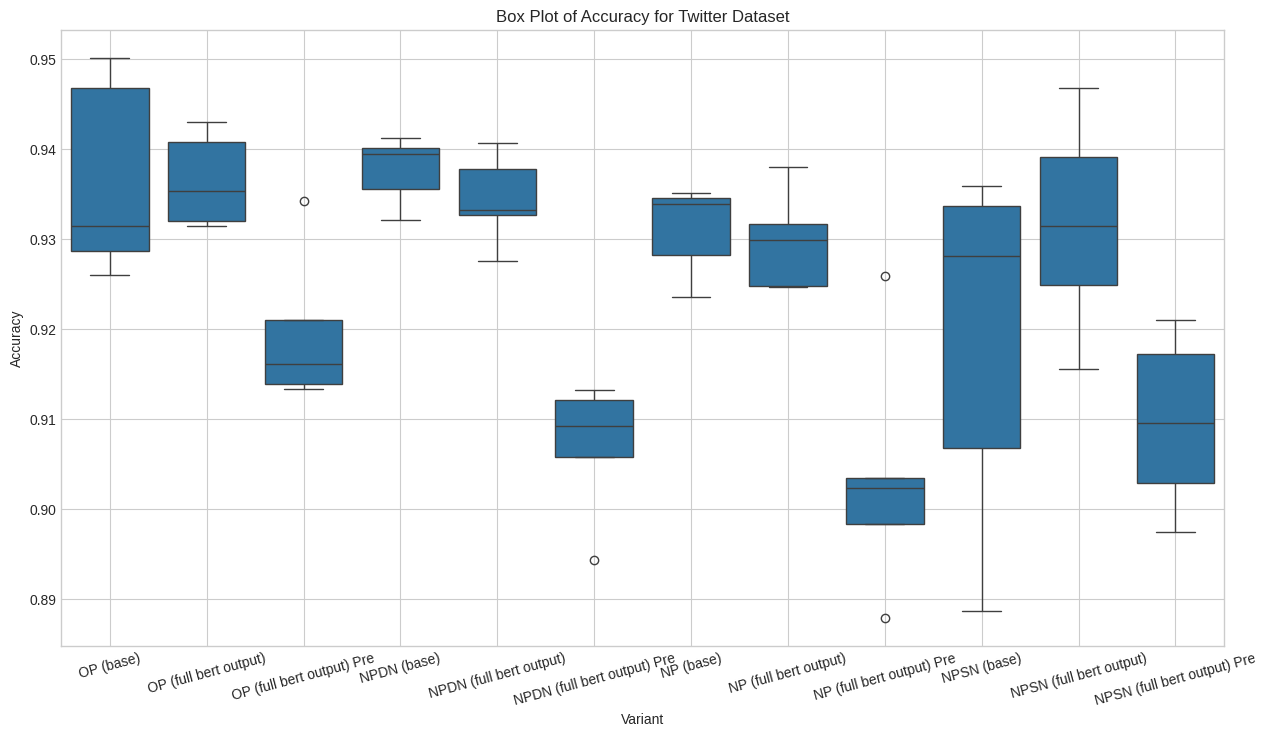

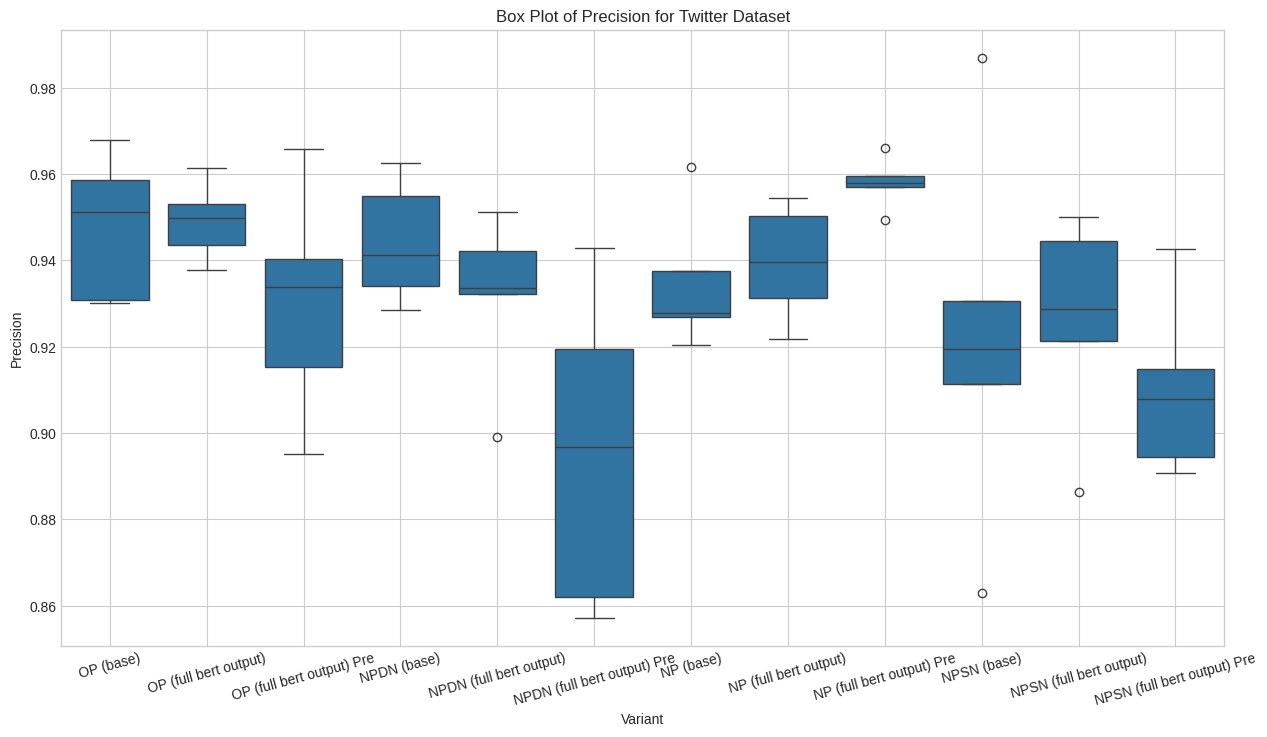

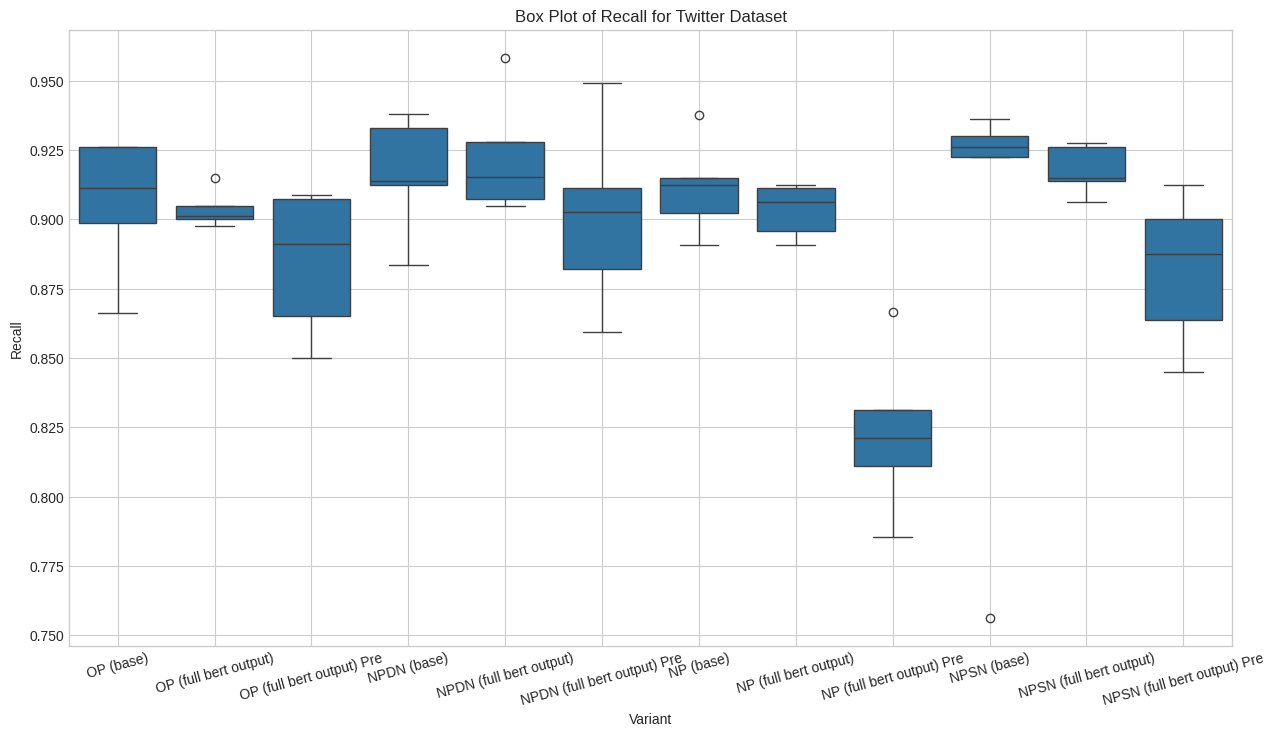

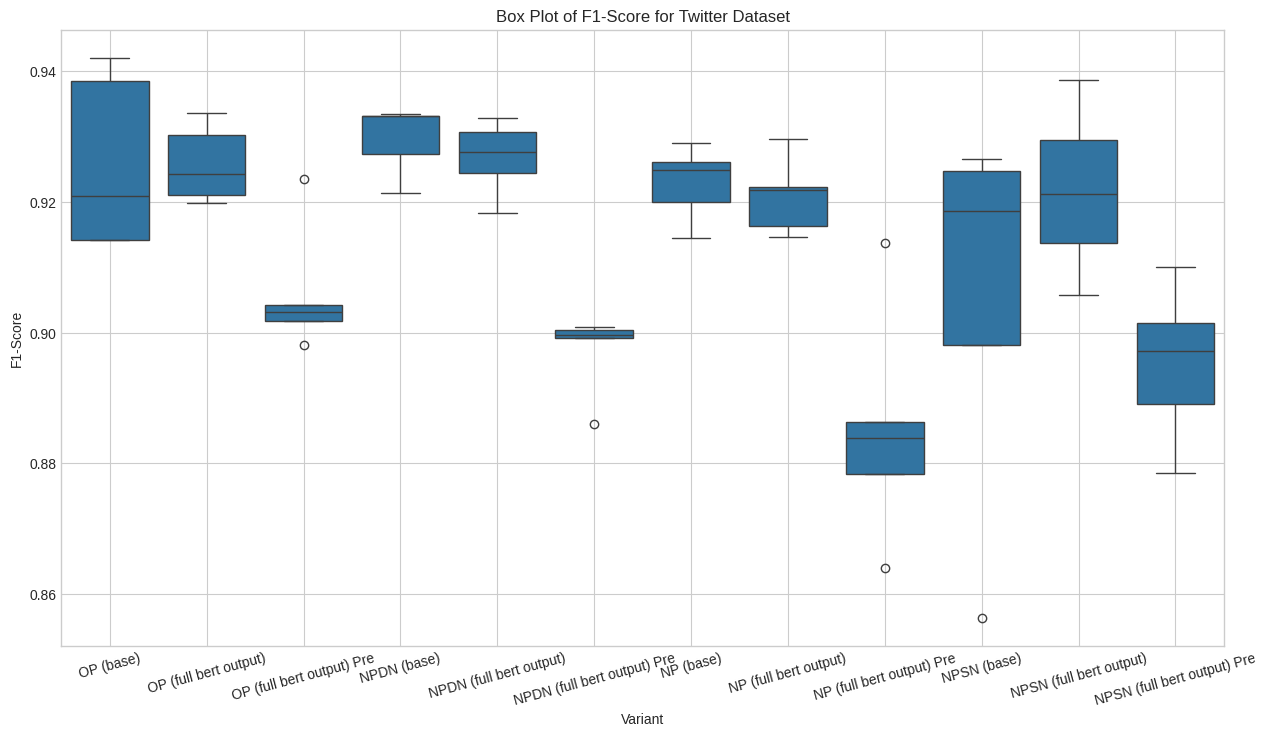

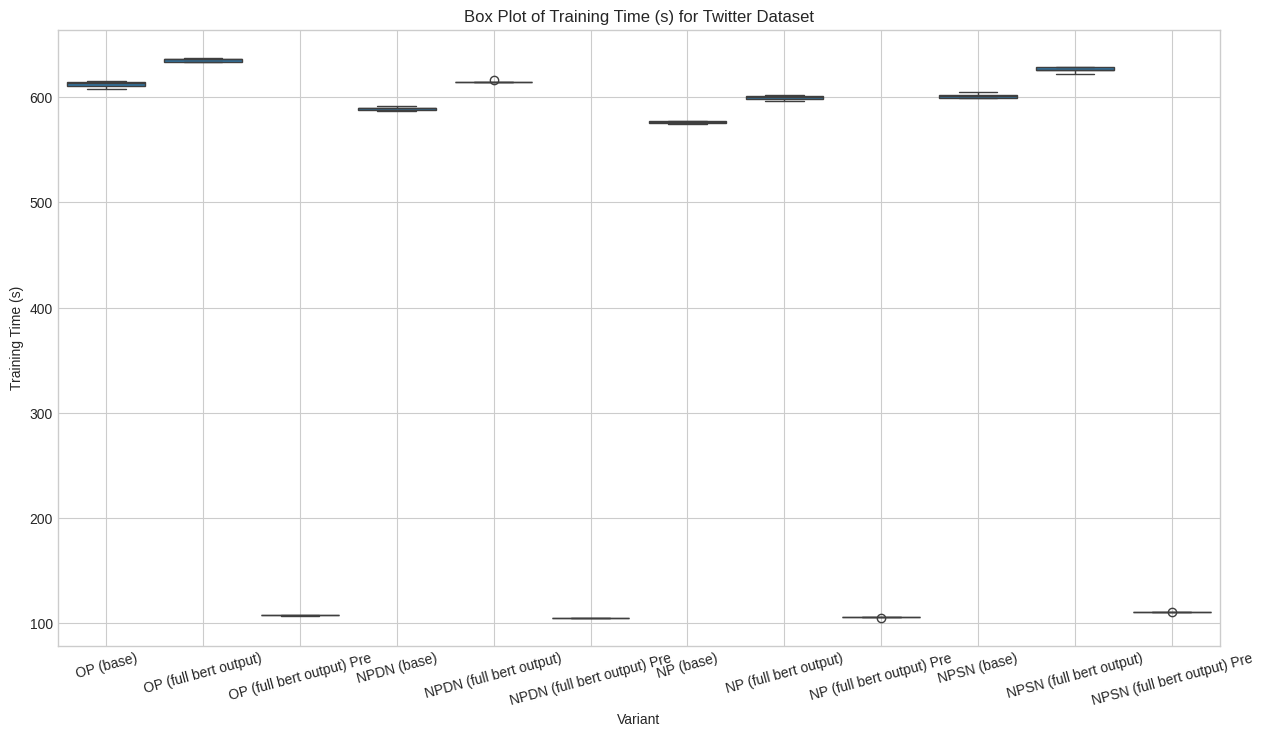





--- Overall Bar Charts for Training Time Comparison ---


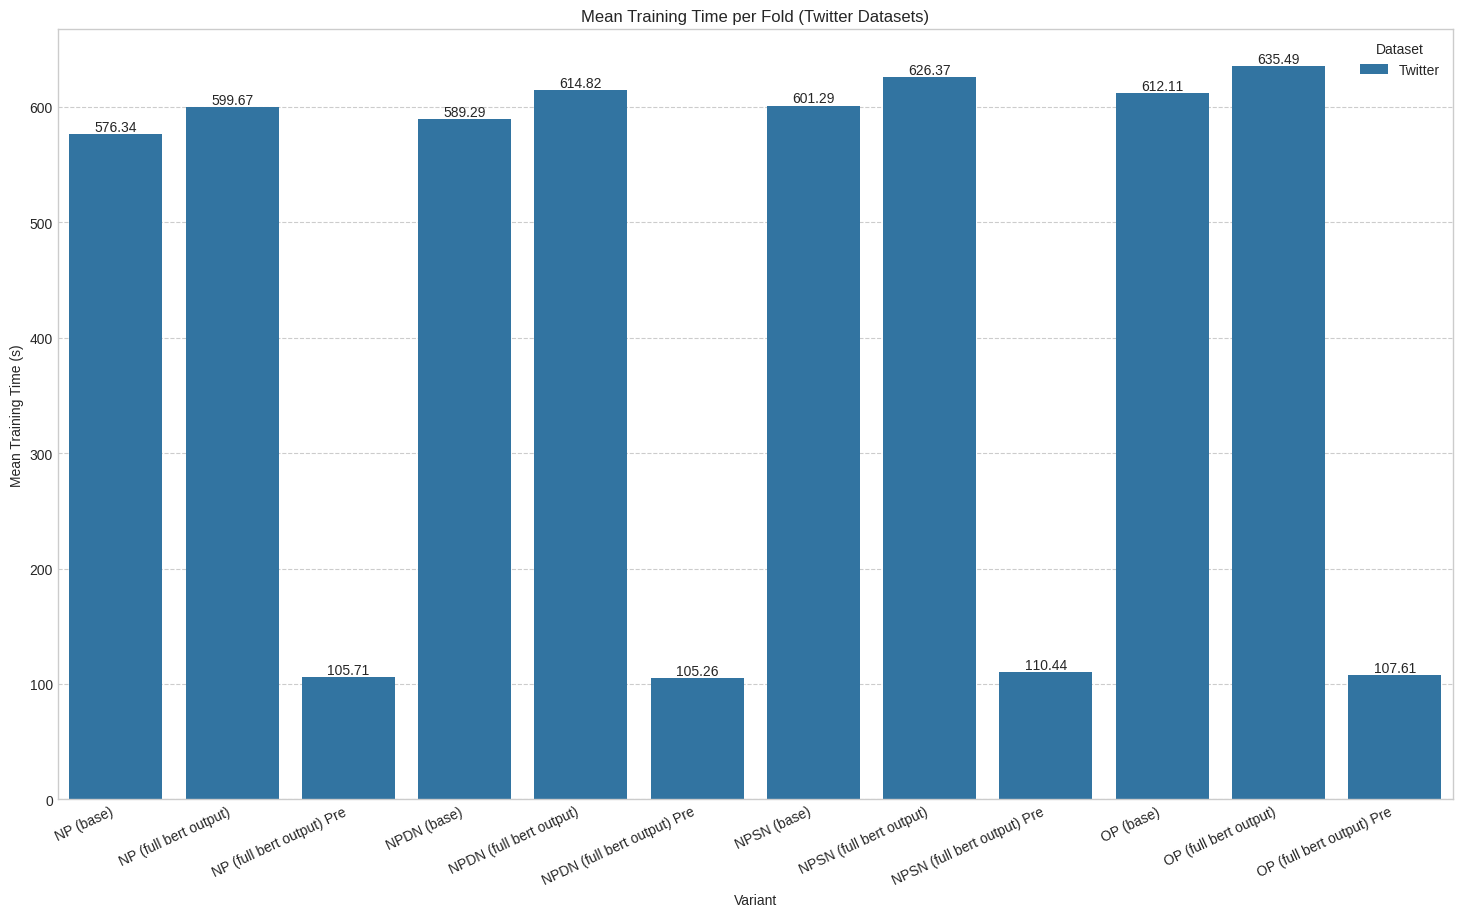

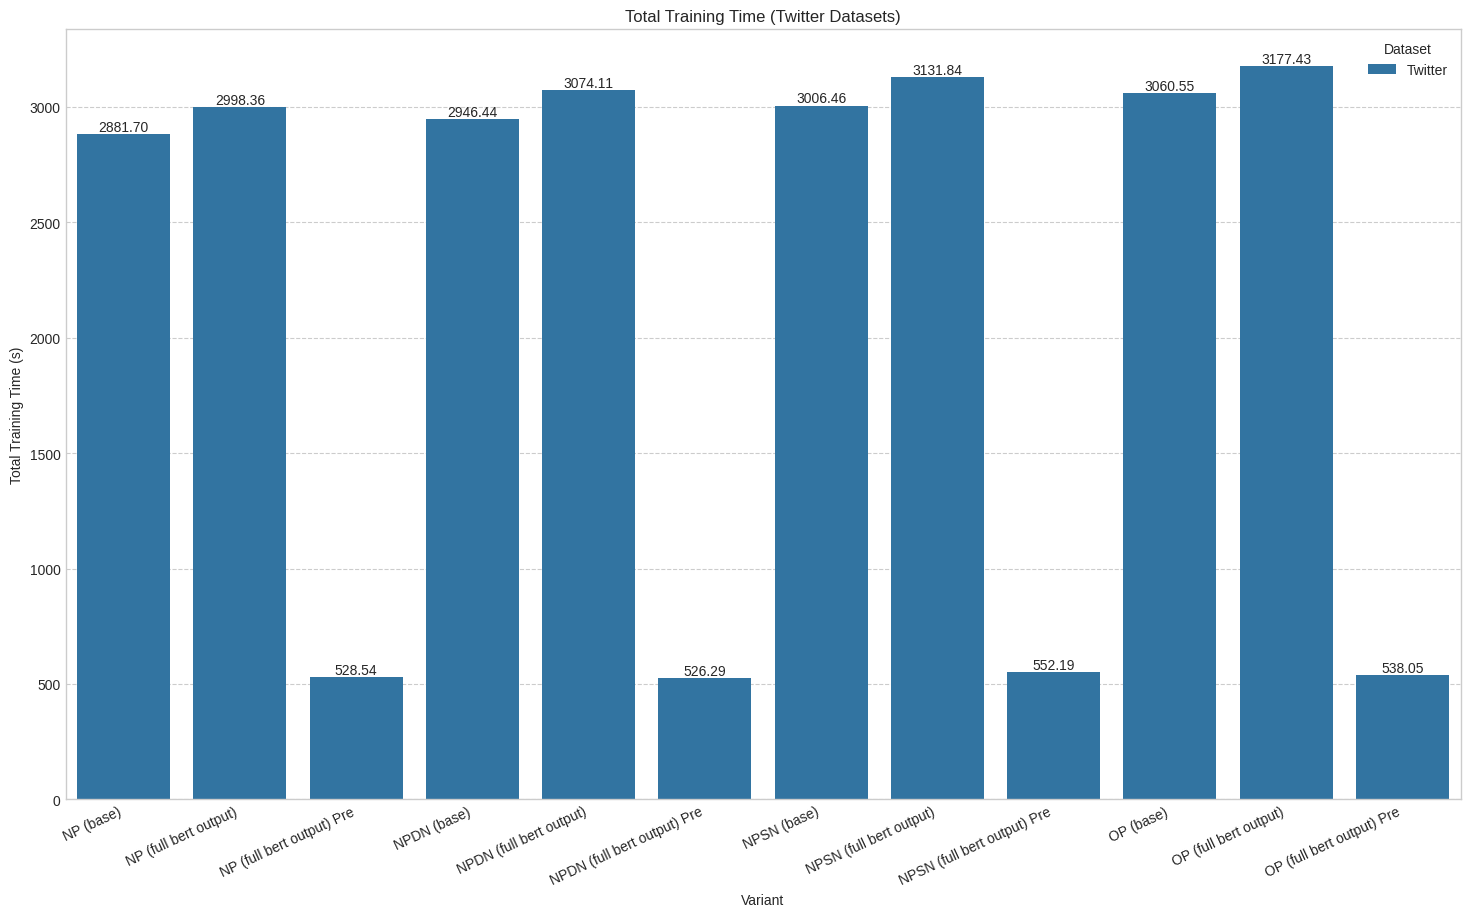

In [ ]:
summary_stats = analyze_model_performance(all_results)

output_filename = '/content/drive/MyDrive/final_FYP_results/twitter_results_preprocess.csv'
all_results_pd = pd.concat(all_results, ignore_index=True)
all_results_pd.to_csv(output_filename, index=False)
summary_stats.to_csv('/content/drive/MyDrive/final_FYP_results/twitter_summary_stats_preprocess.csv')